# Efficiency Wages with Motivated Agents: Analysis Notebook

This notebook is a self-contained walkthrough of the analysis for the paper and online appendix. It starts from the public raw CSV inputs, derives the analysis datasets, runs the Stata regressions through `pystata`, and generates the paper and appendix tables and figures.

Publication: https://www.sciencedirect.com/science/article/pii/S0899825624000307?via%3Dihub

## 1. Setup

The notebook uses Python for data assembly, table formatting, and figures. It uses `pystata` for the regression tables. If Stata is not found automatically, set `STATA_PATH` to the full Stata executable path before starting Jupyter.

In [1]:
from __future__ import annotations

import math
import os
import platform
import shutil
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 160)
sns.set_theme(style="ticks", context="paper", font_scale=1.25)

ROOT = Path.cwd()
DATA_RAW = ROOT / "data" / "raw"
DATA_DERIVED = ROOT / "data" / "derived"
RESULTS = ROOT / "results"
PAPER_TABLES = RESULTS / "paper" / "tables"
PAPER_FIGURES = RESULTS / "paper" / "figures"
APPENDIX_TABLES = RESULTS / "appendix" / "tables"
APPENDIX_FIGURES = RESULTS / "appendix" / "figures"
INTERMEDIATE = RESULTS / "_intermediate"
INTERMEDIATE_TABLES = INTERMEDIATE / "tables"
INTERMEDIATE_LOGS = INTERMEDIATE / "logs"
INTERMEDIATE_FIGURES = INTERMEDIATE / "figures"

for folder in [DATA_DERIVED, PAPER_TABLES, PAPER_FIGURES, APPENDIX_TABLES, APPENDIX_FIGURES, INTERMEDIATE_TABLES, INTERMEDIATE_LOGS, INTERMEDIATE_FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)

WAGES = [1, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 75, 85, 95]
TREATMENT_LABELS = {"P": "GE", "S": "Prosocial", "N": "Neutral", "PAN": "Efficiency"}
RAW_COMBINED = {
    "ge_prosocial": DATA_RAW / "ge_prosocial" / "combined.csv",
    "neutral": DATA_RAW / "neutral" / "combined.csv",
    "efficiency": DATA_RAW / "efficiency" / "combined.csv",
}

## 2. Raw Treatment Data

The analysis starts from the three public `combined.csv` files. The GE and prosocial treatments are in the same raw file; the neutral and efficiency files receive their treatment labels below.

In [2]:
raw = {name: pd.read_csv(path) for name, path in RAW_COMBINED.items()}
raw["neutral"]["Treatment"] = "N"
raw["efficiency"]["Treatment"] = "PAN"

raw_summary = pd.DataFrame(
    [
        {"input": name, "path": str(path.relative_to(ROOT)), "rows": len(raw[name]), "columns": len(raw[name].columns)}
        for name, path in RAW_COMBINED.items()
    ]
)
display(raw_summary)

,input,path,rows,columns
0,ge_prosocial,data/raw/ge_prosocial/combined.csv,190,176
1,neutral,data/raw/neutral/combined.csv,90,192
2,efficiency,data/raw/efficiency/combined.csv,120,169


## 3. Derive The Analysis Datasets

This section constructs the variables used by the paper and appendix analysis, then reshapes the wage-level agent choices and principal beliefs into long format.

In [3]:
ULTIMATUM_ACCEPT_PREFIX = "Ultimatum_Accept_Agent_atShare_Principal_"


def minimum_ug_offer(row: pd.Series) -> int:
    for principal_share, minimum_agent_share in [
        (90, 10),
        (80, 20),
        (70, 30),
        (60, 40),
        (50, 50),
        (40, 60),
        (30, 70),
        (20, 80),
        (10, 90),
    ]:
        if row.get(f"{ULTIMATUM_ACCEPT_PREFIX}{principal_share}", 0) == 1:
            return minimum_agent_share
    return 100


def charitable_giving_for_neutral(row: pd.Series) -> float:
    if row["Agent"] == 1:
        self_cols = ["P1Self1", "P1Self2", "P1Self3", "P1Self4", "P1Self5"]
        return 100 - row[self_cols].mean()
    return 100 - row["P1SelfP"]


def standardize_frame(frame: pd.DataFrame, source_treatment: str) -> pd.DataFrame:
    frame = frame.copy()
    frame["source_treatment"] = source_treatment
    frame["Agent"] = (frame["Type"] == 2).astype(int)
    frame["treatment_label"] = frame["Treatment"].map(TREATMENT_LABELS)
    frame["giveC"] = frame.apply(charitable_giving_for_neutral, axis=1) if source_treatment == "neutral" else frame["DictatorCharity"]
    agents = frame["Agent"] == 1
    frame.loc[agents, "min_ug"] = frame.loc[agents].apply(minimum_ug_offer, axis=1)
    return frame


def make_agent_long(df: pd.DataFrame) -> pd.DataFrame:
    agent = df[df["Agent"] == 1].copy().reset_index(drop=True)
    agent["n"] = np.arange(len(agent))
    base_cols = [
        "n",
        "Treatment",
        "treatment_label",
        "gender",
        "age",
        "study",
        "DictatorCharity",
        "giveC",
        "min_ug",
        "Favor_intentions",
        "Favor_revenge",
        "Favor_return",
        "Punish_Self",
        "Punish_Others",
        "Gift",
        "Give_Charity",
        "Donation_Good_Cause",
    ]
    rows = []
    for wage in WAGES:
        rows.append(
            pd.DataFrame(
                {
                    **{col: agent[col].to_numpy() for col in base_cols if col in agent.columns},
                    "Wage": wage,
                    "Effort": agent[f"PA_OfferedEffort_Agent_atWage_{wage}"].fillna(0).to_numpy(),
                    "Acceptance": agent[f"PA_Accept_Agent_atWage_{wage}"].fillna(0).to_numpy(),
                }
            )
        )
    return pd.concat(rows, ignore_index=True).sort_values(["n", "Wage"])


def make_principal_long(df: pd.DataFrame) -> pd.DataFrame:
    principals = df[df["Agent"] == 0].copy().reset_index(drop=True)
    principals["principal_n"] = np.arange(len(principals))
    base_cols = [
        "principal_n",
        "Treatment",
        "treatment_label",
        "PA_Offer_Principal",
        "PAWage",
        "OptimalWage",
        "real_profitmax_wage",
        "DictatorCharity",
        "giveC",
        "gender",
        "age",
        "study",
    ]
    rows = []
    for wage in WAGES:
        rows.append(
            pd.DataFrame(
                {
                    **{col: principals[col].to_numpy() for col in base_cols if col in principals.columns},
                    "Wage": wage,
                    "ExpectedAcceptance": principals[f"PA_ExpectedAcceptance_Principal_atWage_{wage}"].fillna(0).to_numpy(),
                    "ExpectedEffort": principals[f"PA_ExpectedEffort_Principal_atWage_{wage}"].fillna(0).to_numpy(),
                }
            )
        )
    return pd.concat(rows, ignore_index=True).sort_values(["principal_n", "Wage"])

In [4]:
standardized = {name: standardize_frame(frame, name) for name, frame in raw.items()}
analysis_sample = pd.concat(
    [standardized["ge_prosocial"], standardized["neutral"], standardized["efficiency"]],
    ignore_index=True,
    sort=False,
)
agent_wage_long = make_agent_long(analysis_sample)
principal_beliefs_long = make_principal_long(analysis_sample)
principals = analysis_sample[analysis_sample["Agent"] == 0].copy().reset_index(drop=True)
principals["principal_n"] = np.arange(len(principals))

analysis_sample.to_csv(DATA_DERIVED / "analysis_sample.csv", index=False)
agent_wage_long.to_csv(DATA_DERIVED / "agent_wage_long.csv", index=False)
principal_beliefs_long.to_csv(DATA_DERIVED / "principal_beliefs_long.csv", index=False)
principals.to_csv(DATA_DERIVED / "principals.csv", index=False)

sample_counts = (
    analysis_sample.groupby("Treatment")
    .agg(observations=("Treatment", "size"), agents=("Agent", "sum"))
    .assign(principals=lambda d: d["observations"] - d["agents"])
    .reset_index()
)
display(sample_counts)

,Treatment,observations,agents,principals
0,N,90,45,45
1,P,94,47,47
2,PAN,120,60,60
3,S,96,48,48


## 4. Table Formatting Helpers

The Stata regressions below write long-form coefficient files. These helpers convert those files into readable CSV and LaTeX table fragments.

In [5]:
TABLE_NAMES = {
    "Table 2": "table_2_acceptance",
    "Table 3": "table_3_effort",
    "Table 4": "table_4_wage_offers",
    "Table A.1": "table_a1_summary_statistics",
    "Table A.2": "table_a2_effort_ge_prosocial",
    "Table A.3": "table_a3_effort_neutral_efficiency",
    "Table A.4": "table_a4_acceptance_neutral",
    "Table A.5": "table_a5_acceptance_efficiency",
    "Table A.6": "table_a6_effort_neutral",
    "Table A.7": "table_a7_effort_efficiency",
    "Table A.8": "table_a8_wage_offers_neutral",
    "Table A.9": "table_a9_wage_offers_efficiency",
}


def p_value(coefficient: float, std_error: float) -> float | None:
    if not math.isfinite(coefficient) or not math.isfinite(std_error) or std_error == 0:
        return None
    return 2 * (1 - NormalDist().cdf(abs(coefficient / std_error)))


def stars(value: float | None) -> str:
    if value is None:
        return ""
    if value < 0.01:
        return "***"
    if value < 0.05:
        return "**"
    if value < 0.1:
        return "*"
    return ""


def fmt_number(value: float | int | None, digits: int = 3) -> str:
    if value is None or pd.isna(value):
        return ""
    return f"{float(value):.{digits}f}"


def latex_escape(value: object) -> str:
    text = "" if value is None else str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def write_latex(table: pd.DataFrame, path: Path) -> None:
    cols = list(table.columns)
    lines = [
        r"\begin{tabular}{l" + "c" * (len(cols) - 1) + "}",
        r"\hline",
        " & ".join(latex_escape(col) for col in cols) + r" \\",
        r"\hline",
    ]
    for _, row in table.iterrows():
        lines.append(" & ".join(latex_escape(row[col]) for col in cols) + r" \\")
    lines.extend([r"\hline", r"\end{tabular}", ""])
    path.write_text("\n".join(lines))


def add_p_values(table: pd.DataFrame) -> pd.DataFrame:
    table = table.copy()
    def compute_p(row: pd.Series) -> float | None:
        if pd.notna(row.get("coefficient")) and pd.notna(row.get("std_error")):
            return p_value(float(row["coefficient"]), float(row["std_error"]))
        return None
    table["p_value"] = table.apply(compute_p, axis=1)  # type: ignore[arg-type]
    return table

def formatted_regression_table(group: pd.DataFrame) -> pd.DataFrame:
    group = add_p_values(group)
    models = list(dict.fromkeys(group["model"].astype(str)))
    rows = []
    for term in dict.fromkeys(group["term"]):
        coef_row = {"Term": term}
        se_row = {"Term": ""}
        for model in models:
            match = group[(group["model"].astype(str) == model) & (group["term"] == term)]
            if match.empty:
                coef_row[model] = ""
                se_row[model] = ""
                continue
            row = match.iloc[0]
            coef_row[model] = fmt_number(row["coefficient"]) + stars(row.get("p_value"))
            se_row[model] = f"({fmt_number(row['std_error'])})" if pd.notna(row["std_error"]) else ""
        rows.extend([coef_row, se_row])
    observations = {"Term": "Observations"}
    fit = {"Term": "R-squared / pseudo R-squared"}
    for model in models:
        model_rows = group[group["model"].astype(str) == model]
        observations[model] = str(int(model_rows["observations"].dropna().iloc[0]))
        fit_values = model_rows["fit_stat"].dropna()
        fit[model] = fmt_number(fit_values.iloc[0]) if not fit_values.empty else ""
    rows.extend([observations, fit])
    return pd.DataFrame(rows)


def format_summary_table(path: Path) -> pd.DataFrame:
    table = pd.read_csv(path)
    table["value"] = table.apply(lambda row: f"{row['mean']:.3f} ({row['std_dev']:.3f})", axis=1)
    wide = table.pivot_table(index="variable", columns="treatment", values="value", aggfunc="first", sort=False).fillna("")
    wide.loc["N"] = table.groupby("treatment", sort=False)["observations"].first().astype(str)
    return wide.reset_index().rename(columns={"variable": "Variable"})


def write_table_pair(table: pd.DataFrame, folder: Path, name: str) -> dict[str, str]:
    folder.mkdir(parents=True, exist_ok=True)
    csv_path = folder / f"{name}.csv"
    tex_path = folder / f"{name}.tex"
    table.to_csv(csv_path, index=False)
    write_latex(table, tex_path)
    return {"csv": str(csv_path), "tex": str(tex_path)}


def format_regression_outputs(source: Path, table_ids: set[str] | None = None) -> dict[str, dict[str, str]]:
    artifacts = {}
    raw_results = add_p_values(pd.read_csv(source))
    raw_results.to_csv(source, index=False)
    for table_id, group in raw_results.groupby("table_id", sort=False):
        if table_ids is not None and table_id not in table_ids:
            continue
        folder = PAPER_TABLES if table_id in {"Table 2", "Table 3", "Table 4"} else APPENDIX_TABLES
        artifacts[table_id] = write_table_pair(formatted_regression_table(group), folder, TABLE_NAMES[table_id])
    return artifacts


## 5. Configure Stata For Notebook Regressions

This notebook uses `pystata` so that the Stata regressions run from the notebook state. The Stata commands are shown inline in later cells.

In [6]:
def candidate_stata_executables() -> list[Path]:
    paths = [
        Path("/Applications/Stata/StataSE.app/Contents/MacOS/stata-se"),
        Path("/Applications/Stata/StataMP.app/Contents/MacOS/stata-mp"),
        Path("/Applications/Stata/StataBE.app/Contents/MacOS/stata-be"),
        Path("/usr/local/stata/stata-se"),
        Path("/usr/local/stata/stata-mp"),
        Path("/usr/local/stata/stata-be"),
        Path("/usr/local/bin/stata-se"),
        Path("/usr/local/bin/stata-mp"),
        Path("/usr/local/bin/stata-be"),
    ]
    windows_roots = [os.environ.get("ProgramFiles"), os.environ.get("ProgramFiles(x86)"), os.environ.get("LOCALAPPDATA")]
    windows_names = ["StataSE-64.exe", "StataMP-64.exe", "StataBE-64.exe", "StataSE.exe", "StataMP.exe", "StataBE.exe", "Stata.exe"]
    for root in [Path(value) for value in windows_roots if value]:
        for version in range(25, 16, -1):
            for executable in windows_names:
                paths.append(root / f"Stata{version}" / executable)
                paths.append(root / "Stata" / executable)
    return paths


def find_stata_executable() -> Path:
    if os.environ.get("STATA_PATH"):
        candidate = Path(os.environ["STATA_PATH"]).expanduser()
        if not candidate.is_file():
            raise FileNotFoundError(f"STATA_PATH does not point to a Stata executable: {candidate}")
        return candidate
    for name in ["stata-se", "stata-mp", "stata-be", "stata", "StataSE-64.exe", "StataMP-64.exe", "StataBE-64.exe", "Stata.exe"]:
        found = shutil.which(name)
        if found:
            return Path(found)
    for candidate in candidate_stata_executables():
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find Stata. Set STATA_PATH to the full Stata executable path.")


def stata_edition(executable: Path) -> str:
    name = executable.name.lower()
    if "mp" in name:
        return "mp"
    if "be" in name:
        return "be"
    return "se"


def stata_install_dir(executable: Path) -> Path:
    parts = list(executable.parts)
    for app_name in ["StataSE.app", "StataMP.app", "StataBE.app"]:
        if app_name in parts:
            return Path(*parts[: parts.index(app_name)])
    return executable.parent


stata_executable = find_stata_executable()
stata_dir = stata_install_dir(stata_executable)
edition = stata_edition(stata_executable)

import stata_setup
try:
    stata_setup.config(str(stata_dir), edition, splash=False)
except TypeError:
    stata_setup.config(str(stata_dir), edition)

from pystata import stata
stata.run("display c(stata_version)")
display(pd.DataFrame([{"stata_executable": str(stata_executable), "stata_setup_directory": str(stata_dir), "edition": edition}]))

19


,stata_executable,stata_setup_directory,edition
0,/Applications/Stata/StataSE.app/Contents/MacOS...,/Applications/Stata,se


## 6. Main Paper Regression Tables: Tables 2-4

The Stata commands below estimate the main paper regression tables from the derived datasets created above. The commands are inline rather than called from an external do-file.

In [7]:
%%capture
main_stata_code = r"""
version 17
set more off

capture mkdir results
capture mkdir results/_intermediate
capture mkdir results/_intermediate/tables
capture mkdir results/_intermediate/logs
log using results/_intermediate/logs/stata_main_tables.log, replace text

tempname results
postfile `results' str12 table_id str8 model str48 term double coefficient std_error fit_stat observations using results/_intermediate/tables/main_tables_results.dta, replace

import delimited data/derived/agent_wage_long.csv, clear varnames(1)
keep if treatment == "P" | treatment == "S"
generate treatmentS = treatment == "S"
generate wage_below_5 = .
replace wage_below_5 = 0 if wage > 3
replace wage_below_5 = 1 if wage < 5
xtset n

quietly xtreg acceptance c.wage_below_5, re cluster(n)
post `results' ("Table 2") ("1") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (e(r2_o)) (e(N))
post `results' ("Table 2") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg acceptance c.wage_below_5##c.treatmentS, re cluster(n)
post `results' ("Table 2") ("2") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (e(r2_o)) (e(N))
post `results' ("Table 2") ("2") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (e(r2_o)) (e(N))
post `results' ("Table 2") ("2") ("Wage<5*Prosocial treatment") (_b[c.wage_below_5#c.treatmentS]) (_se[c.wage_below_5#c.treatmentS]) (e(r2_o)) (e(N))
post `results' ("Table 2") ("2") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg acceptance c.wage_below_5##c.treatmentS i.gender i.study age, re cluster(n)
post `results' ("Table 2") ("3") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (e(r2_o)) (e(N))
post `results' ("Table 2") ("3") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (e(r2_o)) (e(N))
post `results' ("Table 2") ("3") ("Wage<5*Prosocial treatment") (_b[c.wage_below_5#c.treatmentS]) (_se[c.wage_below_5#c.treatmentS]) (e(r2_o)) (e(N))
post `results' ("Table 2") ("3") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtlogit acceptance c.wage_below_5, re vce(cluster n)
post `results' ("Table 2") ("4") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (.) (e(N))
post `results' ("Table 2") ("4") ("Constant") (_b[_cons]) (_se[_cons]) (.) (e(N))

quietly xtlogit acceptance c.wage_below_5##c.treatmentS, re vce(cluster n)
post `results' ("Table 2") ("5") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (.) (e(N))
post `results' ("Table 2") ("5") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (.) (e(N))
post `results' ("Table 2") ("5") ("Wage<5*Prosocial treatment") (_b[c.wage_below_5#c.treatmentS]) (_se[c.wage_below_5#c.treatmentS]) (.) (e(N))
post `results' ("Table 2") ("5") ("Constant") (_b[_cons]) (_se[_cons]) (.) (e(N))

quietly xtlogit acceptance c.wage_below_5##c.treatmentS i.gender i.study age, re vce(cluster n)
post `results' ("Table 2") ("6") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (.) (e(N))
post `results' ("Table 2") ("6") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (.) (e(N))
post `results' ("Table 2") ("6") ("Wage<5*Prosocial treatment") (_b[c.wage_below_5#c.treatmentS]) (_se[c.wage_below_5#c.treatmentS]) (.) (e(N))
post `results' ("Table 2") ("6") ("Constant") (_b[_cons]) (_se[_cons]) (.) (e(N))

quietly xtreg effort c.wage, re cluster(n)
post `results' ("Table 3") ("1") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
post `results' ("Table 3") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg effort c.wage##c.treatmentS, re cluster(n)
post `results' ("Table 3") ("2") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
post `results' ("Table 3") ("2") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (e(r2_o)) (e(N))
post `results' ("Table 3") ("2") ("Wage*Prosocial treatment") (_b[c.wage#c.treatmentS]) (_se[c.wage#c.treatmentS]) (e(r2_o)) (e(N))
post `results' ("Table 3") ("2") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg effort c.wage##c.treatmentS i.gender i.study age, re cluster(n)
post `results' ("Table 3") ("3") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
post `results' ("Table 3") ("3") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (e(r2_o)) (e(N))
post `results' ("Table 3") ("3") ("Wage*Prosocial treatment") (_b[c.wage#c.treatmentS]) (_se[c.wage#c.treatmentS]) (e(r2_o)) (e(N))
post `results' ("Table 3") ("3") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly tobit effort c.wage, ul(10) ll(0) vce(cluster n)
post `results' ("Table 3") ("4") ("Wage") (_b[wage]) (_se[wage]) (e(r2_p)) (e(N))
post `results' ("Table 3") ("4") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_p)) (e(N))

quietly tobit effort c.wage##c.treatmentS, ul(10) ll(0) vce(cluster n)
post `results' ("Table 3") ("5") ("Wage") (_b[wage]) (_se[wage]) (e(r2_p)) (e(N))
post `results' ("Table 3") ("5") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (e(r2_p)) (e(N))
post `results' ("Table 3") ("5") ("Wage*Prosocial treatment") (_b[c.wage#c.treatmentS]) (_se[c.wage#c.treatmentS]) (e(r2_p)) (e(N))
post `results' ("Table 3") ("5") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_p)) (e(N))

quietly tobit effort c.wage##c.treatmentS i.gender i.study age, ul(10) ll(0) vce(cluster n)
post `results' ("Table 3") ("6") ("Wage") (_b[wage]) (_se[wage]) (e(r2_p)) (e(N))
post `results' ("Table 3") ("6") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (e(r2_p)) (e(N))
post `results' ("Table 3") ("6") ("Wage*Prosocial treatment") (_b[c.wage#c.treatmentS]) (_se[c.wage#c.treatmentS]) (e(r2_p)) (e(N))
post `results' ("Table 3") ("6") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_p)) (e(N))

import delimited data/derived/principals.csv, clear varnames(1)
keep if treatment == "P" | treatment == "S"
generate offered_wage = pa_offer_principal
generate treatmentS = treatment == "S"
generate tSchar = treatmentS * dictatorcharity

quietly regress offered_wage treatmentS, robust
post `results' ("Table 4") ("1") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (e(r2)) (e(N))
post `results' ("Table 4") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

quietly regress offered_wage treatmentS dictatorcharity, robust
post `results' ("Table 4") ("2") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (e(r2)) (e(N))
post `results' ("Table 4") ("2") ("Charitable motivation") (_b[dictatorcharity]) (_se[dictatorcharity]) (e(r2)) (e(N))
post `results' ("Table 4") ("2") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

quietly regress offered_wage treatmentS dictatorcharity tSchar, robust
post `results' ("Table 4") ("3") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (e(r2)) (e(N))
post `results' ("Table 4") ("3") ("Charitable motivation") (_b[dictatorcharity]) (_se[dictatorcharity]) (e(r2)) (e(N))
post `results' ("Table 4") ("3") ("Prosocial treatment*Charitable motivation") (_b[tSchar]) (_se[tSchar]) (e(r2)) (e(N))
post `results' ("Table 4") ("3") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

quietly regress offered_wage treatmentS dictatorcharity tSchar i.gender i.study age, robust
post `results' ("Table 4") ("4") ("Prosocial treatment") (_b[treatmentS]) (_se[treatmentS]) (e(r2)) (e(N))
post `results' ("Table 4") ("4") ("Charitable motivation") (_b[dictatorcharity]) (_se[dictatorcharity]) (e(r2)) (e(N))
post `results' ("Table 4") ("4") ("Prosocial treatment*Charitable motivation") (_b[tSchar]) (_se[tSchar]) (e(r2)) (e(N))
post `results' ("Table 4") ("4") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

postclose `results'

use results/_intermediate/tables/main_tables_results.dta, clear
export delimited using results/_intermediate/tables/main_tables_results.csv, replace

log close

"""

stata.run(main_stata_code)
main_table_artifacts = format_regression_outputs(INTERMEDIATE_TABLES / "main_tables_results.csv", {"Table 2", "Table 3", "Table 4"})
main_table_artifacts


In [8]:
for title, path in [
    ("Table 2. Acceptance", PAPER_TABLES / "table_2_acceptance.csv"),
    ("Table 3. Effort", PAPER_TABLES / "table_3_effort.csv"),
    ("Table 4. Wage offers", PAPER_TABLES / "table_4_wage_offers.csv"),
]:
    display(Markdown(f"### {title}"))
    display(pd.read_csv(path))

### Table 2. Acceptance

,Term,1,2,3,4,5,6
0,Wage<5,-0.707***,-0.759***,-0.759***,-5.417***,-6.474***,-6.517***
1,NaN,(0.033),(0.040),(0.040),(0.402),(0.756),(0.753)
2,Constant,0.818***,0.802***,0.757***,2.237***,2.012***,1.333
3,NaN,(0.021),(0.033),(0.147),(0.253),(0.284),(1.386)
4,Prosocial treatment,NaN,0.031,0.035,NaN,0.415,0.477
5,NaN,NaN,(0.041),(0.040),NaN,(0.426),(0.418)
6,Wage<5*Prosocial treatment,NaN,0.103,0.103,NaN,1.667*,1.714*
7,NaN,NaN,(0.065),(0.065),NaN,(0.908),(0.904)
8,Observations,1710,1710,1710,1710,1710,1710
9,R-squared / pseudo R-squared,0.256,0.260,0.263,NaN,NaN,NaN


### Table 3. Effort

,Term,1,2,3,4,5,6
0,Wage,0.089***,0.091***,0.091***,0.138***,0.145***,0.145***
1,NaN,(0.005),(0.007),(0.007),(0.008),(0.011),(0.011)
2,Constant,0.620***,0.242*,-2.993**,-1.826***,-2.552***,-7.608***
3,NaN,(0.157),(0.142),(1.239),(0.360),(0.413),(1.946)
4,Prosocial treatment,NaN,0.749**,0.634*,NaN,1.431**,1.340*
5,NaN,NaN,(0.302),(0.374),NaN,(0.626),(0.707)
6,Wage*Prosocial treatment,NaN,-0.004,-0.004,NaN,-0.013,-0.014
7,NaN,NaN,(0.009),(0.009),NaN,(0.016),(0.016)
8,Observations,1710,1710,1710,1710,1710,1710
9,R-squared / pseudo R-squared,0.459,0.466,0.491,0.138,0.141,0.150


### Table 4. Wage offers

,Term,1,2,3,4
0,Prosocial treatment,10.196***,10.187**,14.593**,13.218**
1,NaN,(3.952),(3.958),(5.668),(5.669)
2,Constant,25.574***,24.072***,21.740***,21.360
3,NaN,(2.443),(3.161),(3.589),(13.294)
4,Charitable motivation,NaN,0.098,0.250**,0.145
5,NaN,NaN,(0.110),(0.124),(0.149)
6,Prosocial treatment*Charitable motivation,NaN,NaN,-0.287,-0.182
7,NaN,NaN,NaN,(0.204),(0.203)
8,Observations,95,95,95,95
9,R-squared / pseudo R-squared,0.066,0.073,0.088,0.115


## 7. Main Paper Figures: Figures 2-4

These figures are generated directly from the notebook's derived data.

In [9]:
PROFIT_MULTIPLIER = {"P": 10, "S": 10, "N": 10, "PAN": 35}
DISPLAY_ORDER = ["GE", "Prosocial", "Neutral", "Efficiency"]
BOOTSTRAP_SEED = 2024
WAGE_TYPE_ORDER = [
    "Offered",
    "Expected Profit Maximizing",
    "Guessed Profit Maximizing",
    "Real Profit Maximizing",
]


def profit_max_wage(efforts: list[float], treatment: str) -> int:
    profits = [
        100 if pd.isna(effort) else PROFIT_MULTIPLIER[treatment] * effort - wage + 100
        for effort, wage in zip(efforts, WAGES)
    ]
    return WAGES[int(np.nanargmax(profits))]


def agent_profit_max_wages(df: pd.DataFrame) -> pd.DataFrame:
    agents = df[df["Agent"] == 1].copy().reset_index(drop=True)
    agents["real_profitmax_wage"] = agents.apply(
        lambda row: profit_max_wage(
            [row[f"PA_OfferedEffort_Agent_atWage_{wage}"] for wage in WAGES],
            row["Treatment"],
        ),
        axis=1,
    )
    agents["Treatment label"] = agents["Treatment"].map(TREATMENT_LABELS)
    return agents[["Treatment label", "real_profitmax_wage"]]


def wage_summary_tables(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    principal_rows = df[df["Agent"] == 0].copy().reset_index(drop=True)
    principal_rows["expected_profitmax_wage"] = principal_rows.apply(
        lambda row: profit_max_wage(
            [row[f"PA_ExpectedEffort_Principal_atWage_{wage}"] for wage in WAGES],
            row["Treatment"],
        ),
        axis=1,
    )
    principal_rows["Treatment label"] = principal_rows["Treatment"].map(TREATMENT_LABELS)

    rows = []
    for source_col, wage_type in [
        ("PAWage", "Offered"),
        ("OptimalWage", "Guessed Profit Maximizing"),
        ("expected_profitmax_wage", "Expected Profit Maximizing"),
    ]:
        rows.append(
            principal_rows[["Treatment label", source_col]]
            .rename(columns={"Treatment label": "Treatment", source_col: "Wage"})
            .assign(**{"Wage type": wage_type})
        )
    rows.append(
        agent_profit_max_wages(df)
        .rename(columns={"Treatment label": "Treatment", "real_profitmax_wage": "Wage"})
        .assign(**{"Wage type": "Real Profit Maximizing"})
    )
    return pd.concat(rows, ignore_index=True), principal_rows


def plot_wage_comparison(data: pd.DataFrame, order: list[str]) -> None:
    sns.barplot(
        data=data,
        x="Treatment",
        y="Wage",
        hue="Wage type",
        estimator=np.mean,
        errorbar=("ci", 95),
        seed=BOOTSTRAP_SEED,
        capsize=0.05,
        err_kws={"linewidth": 1},
        linewidth=1,
        edgecolor="black",
        order=order,
        hue_order=WAGE_TYPE_ORDER,
    )
    plt.ylabel("Wage")


def save_current_figure(path: Path, dpi: int = 300) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=dpi)
    plt.close()


wage_summary, wage_summary_by_principal = wage_summary_tables(analysis_sample)
wage_summary_means = (
    wage_summary.groupby(["Treatment", "Wage type"], as_index=False)["Wage"]
    .mean()
    .pivot(index="Treatment", columns="Wage type", values="Wage")
    .reindex(DISPLAY_ORDER)
    .reindex(columns=WAGE_TYPE_ORDER)
)
display(wage_summary_means)


Wage type,Offered,Expected Profit Maximizing,Guessed Profit Maximizing,Real Profit Maximizing
Treatment,,,,
GE,25.574468,24.127660,28.382979,38.638298
Prosocial,35.770833,31.145833,39.770833,29.687500
Neutral,35.200000,26.800000,37.422222,27.066667
Efficiency,46.683333,57.750000,51.016667,63.466667


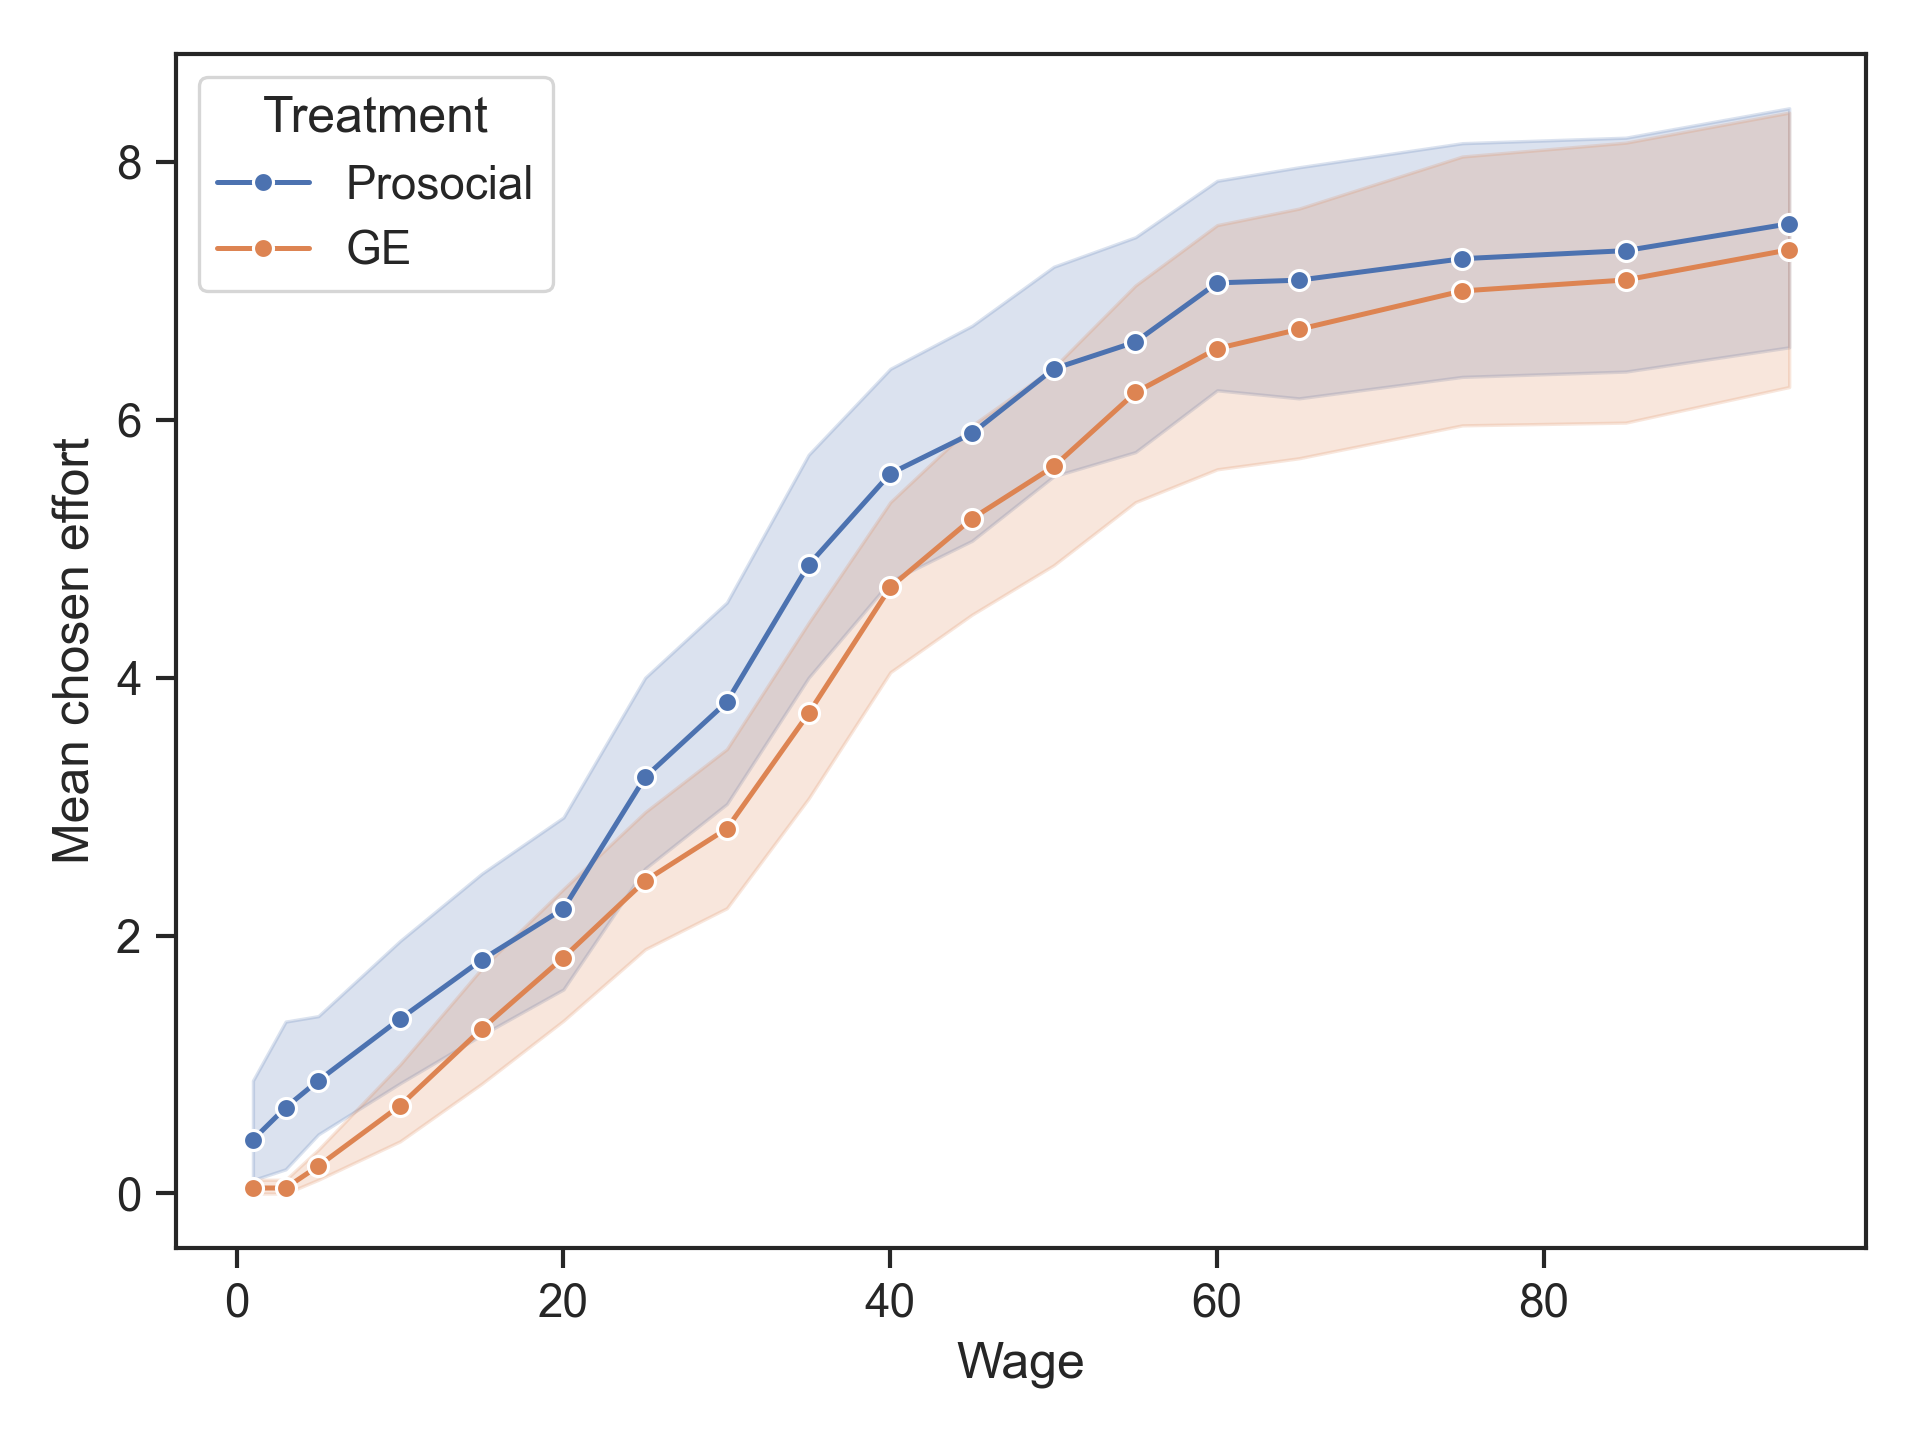

In [10]:
main = agent_wage_long[agent_wage_long["Treatment"].isin(["P", "S"])].copy()
main["Treatment"] = main["treatment_label"]
sns.lineplot(data=main, x="Wage", y="Effort", hue="Treatment", marker="o", errorbar=("ci", 95), seed=BOOTSTRAP_SEED)
plt.ylabel("Mean chosen effort")
save_current_figure(PAPER_FIGURES / "main_fig_2_chosen_effort.png")
display(Image(filename=str(PAPER_FIGURES / "main_fig_2_chosen_effort.png")))


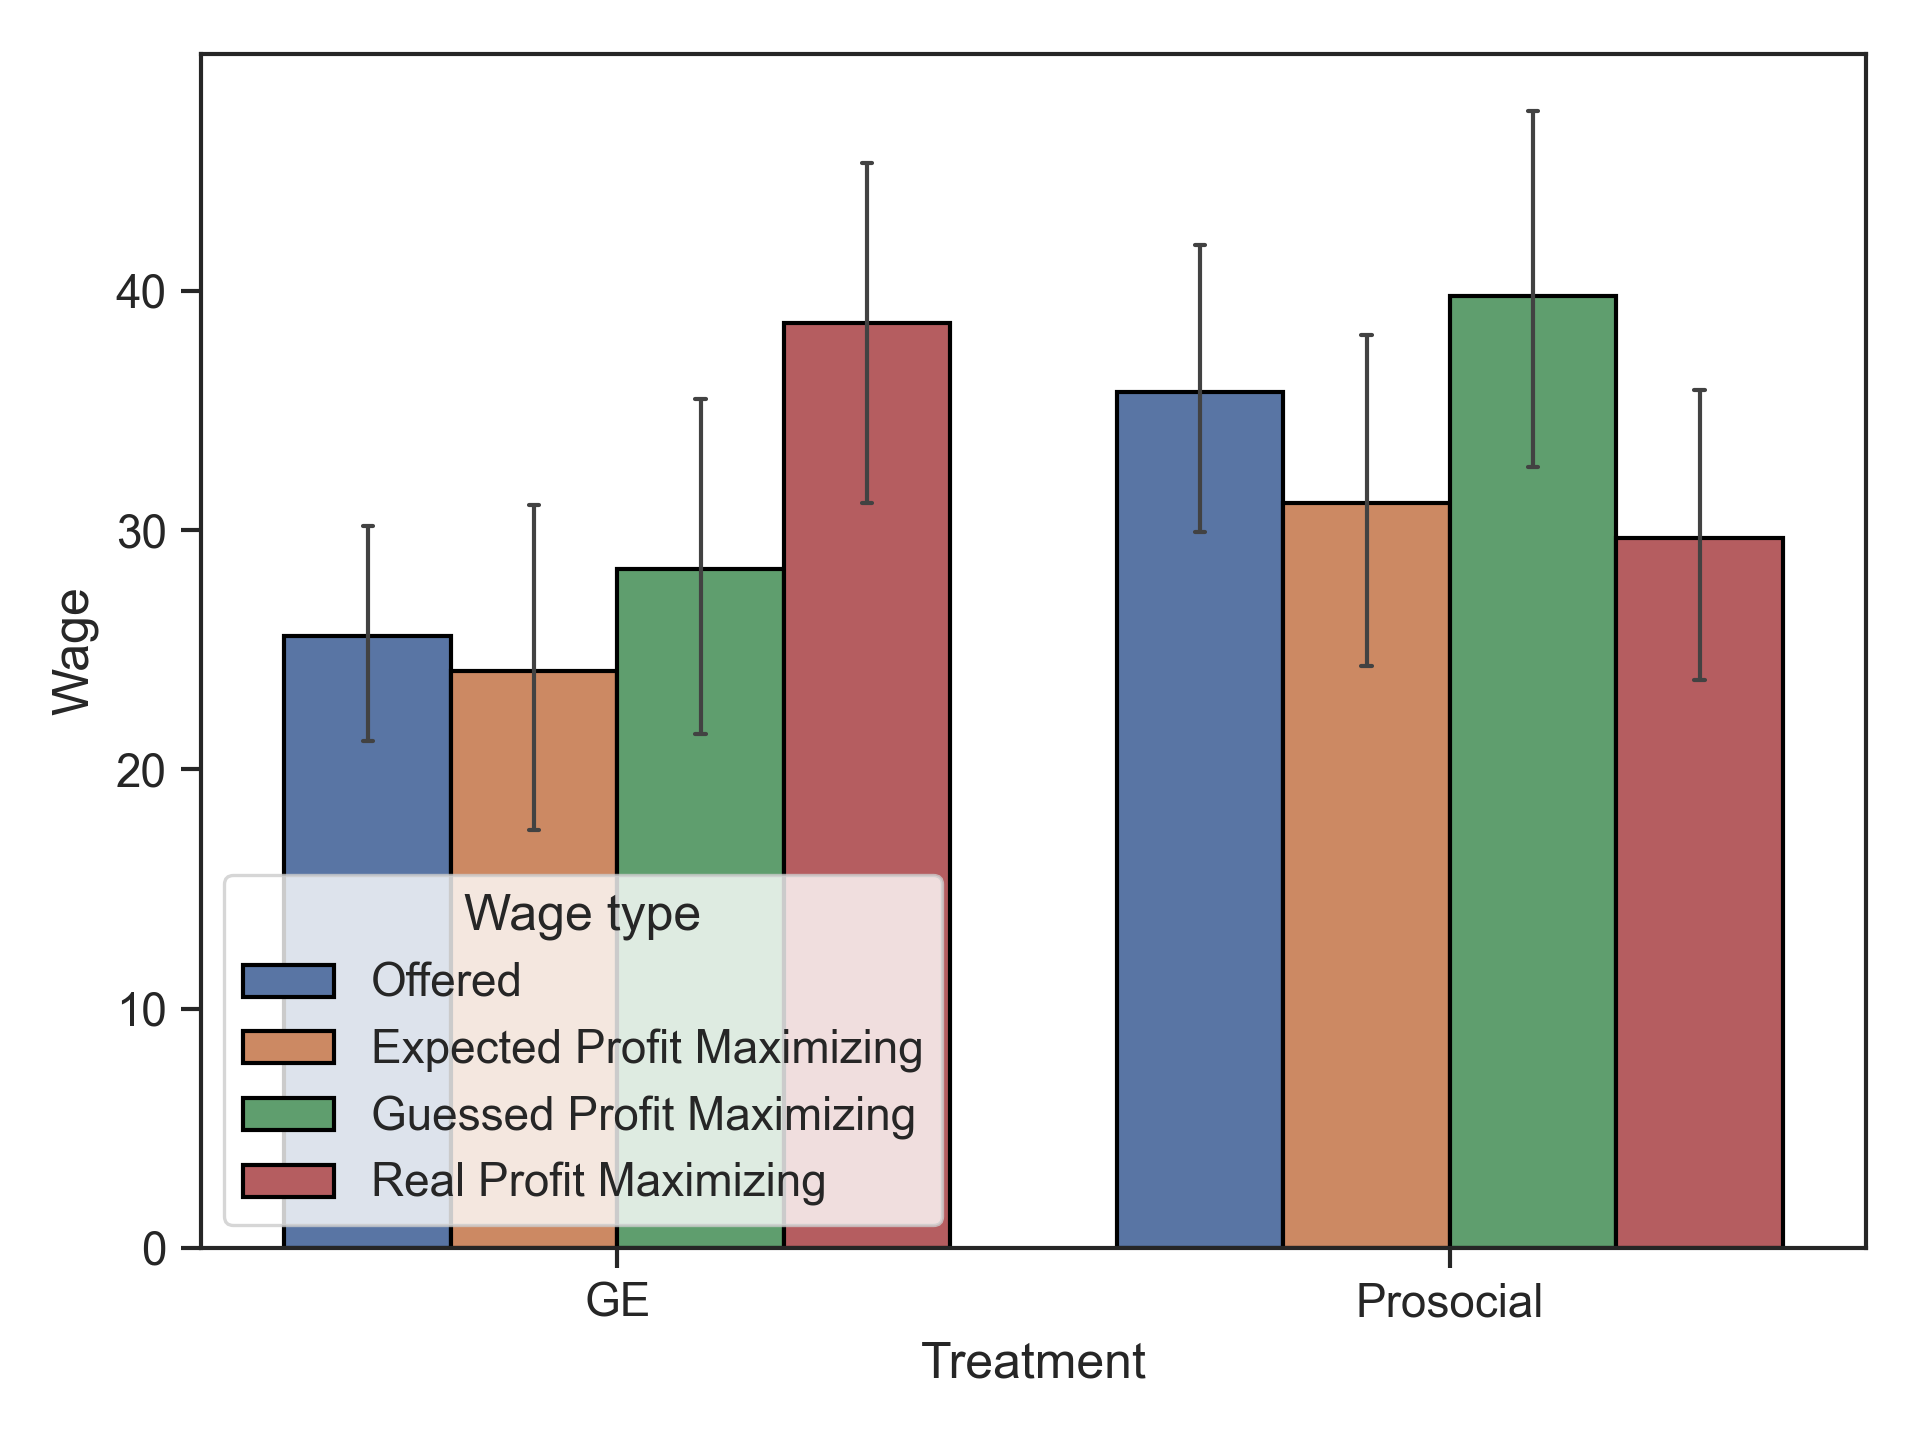

In [11]:

main_wages = wage_summary[wage_summary["Treatment"].isin(["GE", "Prosocial"])]
plot_wage_comparison(main_wages, ["GE", "Prosocial"])
plt.xticks(rotation=0)
save_current_figure(PAPER_FIGURES / "main_fig_3_wage_comparisons.png")
display(Image(filename=str(PAPER_FIGURES / "main_fig_3_wage_comparisons.png")))


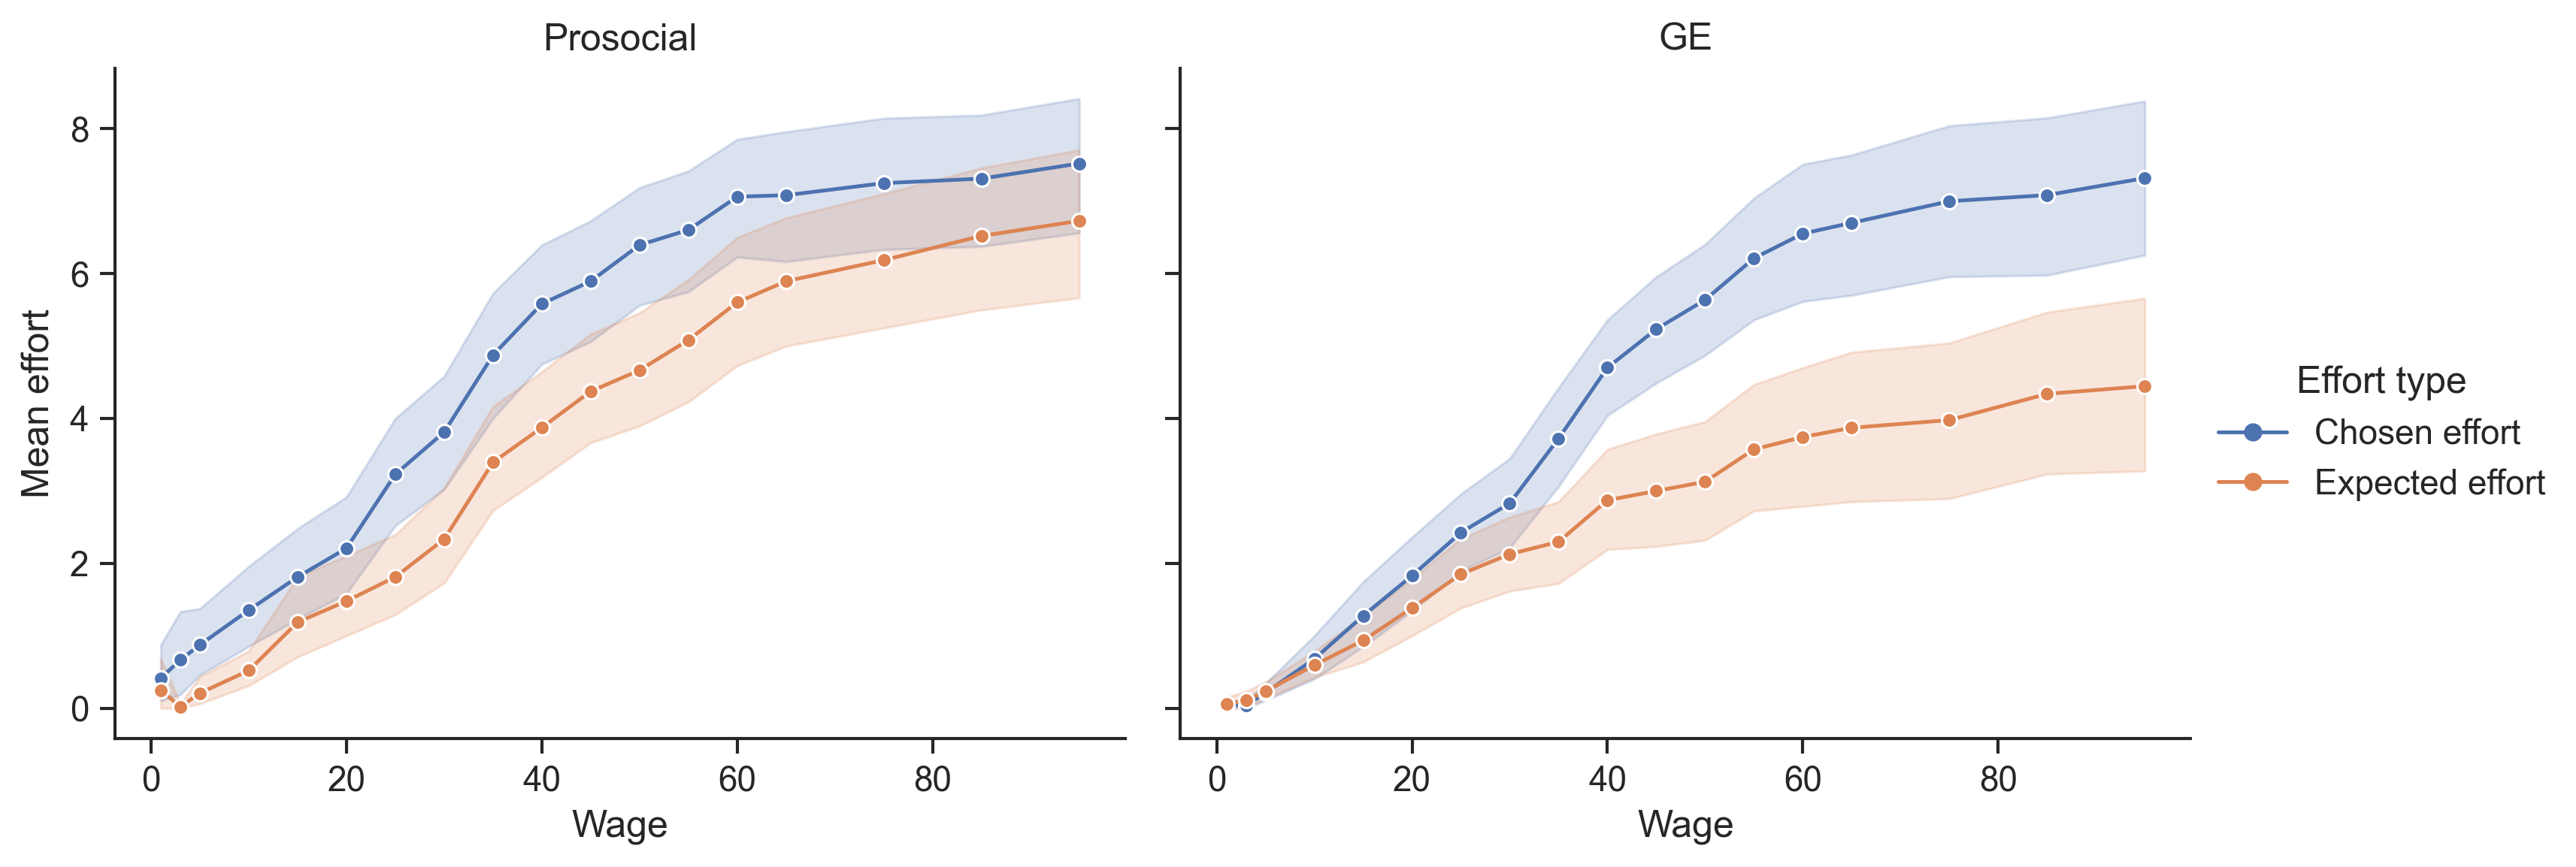

In [12]:
chosen = agent_wage_long[agent_wage_long["Treatment"].isin(["P", "S"])][["Treatment", "treatment_label", "Wage", "Effort"]].copy()
chosen["Effort type"] = "Chosen effort"
expected = principal_beliefs_long[principal_beliefs_long["Treatment"].isin(["P", "S"])][["Treatment", "treatment_label", "Wage", "ExpectedEffort"]].rename(columns={"ExpectedEffort": "Effort"})
expected["Effort type"] = "Expected effort"
beliefs = pd.concat([chosen, expected], ignore_index=True)
g = sns.relplot(data=beliefs, x="Wage", y="Effort", hue="Effort type", col="treatment_label", kind="line", marker="o", errorbar=("ci", 95), seed=BOOTSTRAP_SEED, height=4, aspect=1.25)
g.set_axis_labels("Wage", "Mean effort")
g.set_titles("{col_name}")
g.savefig(PAPER_FIGURES / "main_fig_4_chosen_expected_effort.png", dpi=300)
plt.close("all")
display(Image(filename=str(PAPER_FIGURES / "main_fig_4_chosen_expected_effort.png")))


## 8. Appendix Table A.1: Summary Statistics

Table A.1 is generated in Python from the derived combined sample.

In [13]:
TREATMENT_ORDER = ["P", "S", "N", "PAN"]
TREATMENT_NAMES = {"P": "GE", "S": "Prosocial", "N": "Neutral", "PAN": "Efficiency"}
rows = []
for treatment in TREATMENT_ORDER:
    group = analysis_sample[analysis_sample["Treatment"] == treatment]
    variables = {
        "Age": group["age"],
        "Male": group["gender"],
        "Study subject #1": (group["study"] == 1).astype(int),
        "Study subject #2": (group["study"] == 2).astype(int),
        "Study subject #3": (group["study"] == 3).astype(int),
    }
    for variable, values in variables.items():
        rows.append(
            {
                "table_id": "Table A.1",
                "treatment": TREATMENT_NAMES[treatment],
                "variable": variable,
                "mean": values.mean(),
                "std_dev": values.std(ddof=1),
                "observations": int(values.count()),
            }
        )
summary_statistics = pd.DataFrame(rows)
summary_path = INTERMEDIATE_TABLES / "appendix_table_a1_summary_statistics.csv"
summary_statistics.to_csv(summary_path, index=False)
table_a1 = format_summary_table(summary_path)
write_table_pair(table_a1, APPENDIX_TABLES, TABLE_NAMES["Table A.1"])
display(table_a1)

treatment,Variable,GE,Prosocial,Neutral,Efficiency
0,Age,24.362 (3.849),24.208 (4.052),25.389 (4.749),25.775 (6.627)
1,Male,0.564 (0.499),0.677 (0.470),0.567 (0.498),0.567 (0.498)
2,Study subject #1,0.170 (0.378),0.177 (0.384),0.156 (0.364),0.217 (0.414)
3,Study subject #2,0.213 (0.411),0.198 (0.401),0.189 (0.394),0.192 (0.395)
4,Study subject #3,0.617 (0.489),0.625 (0.487),0.656 (0.478),0.592 (0.494)
5,N,94,96,90,120


## 9. Appendix Regression Tables: Tables A.2-A.9

The Stata commands below estimate the appendix regression tables from the notebook-derived datasets. The commands are inline rather than called from an external do-file.

In [14]:
%%capture
appendix_stata_code = r"""
version 17
set more off

capture mkdir results
capture mkdir results/_intermediate
capture mkdir results/_intermediate/tables
capture mkdir results/_intermediate/logs
log using results/_intermediate/logs/stata_appendix_tables.log, replace text

tempname results
postfile `results' str12 table_id str24 model str64 term double coefficient std_error fit_stat observations using results/_intermediate/tables/appendix_tables_results.dta, replace

import delimited data/derived/agent_wage_long.csv, clear varnames(1)
xtset n

foreach tr in P S {
    local label = cond("`tr'" == "P", "GE", "Prosocial")
    quietly xtreg effort c.wage if treatment == "`tr'", re cluster(n)
    post `results' ("Table A.2") ("`label' real") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
    post `results' ("Table A.2") ("`label' real") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))
}

import delimited data/derived/principal_beliefs_long.csv, clear varnames(1)
xtset principal_n

foreach tr in P S {
    local label = cond("`tr'" == "P", "GE", "Prosocial")
    quietly xtreg expectedeffort c.wage if treatment == "`tr'", re cluster(principal_n)
    post `results' ("Table A.2") ("`label' expected") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
    post `results' ("Table A.2") ("`label' expected") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))
}

import delimited data/derived/agent_wage_long.csv, clear varnames(1)
xtset n

foreach tr in N PAN {
    local label = cond("`tr'" == "N", "Neutral", "Efficiency")
    quietly xtreg effort c.wage if treatment == "`tr'", re cluster(n)
    post `results' ("Table A.3") ("`label' real") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
    post `results' ("Table A.3") ("`label' real") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))
}

import delimited data/derived/principal_beliefs_long.csv, clear varnames(1)
xtset principal_n

foreach tr in N PAN {
    local label = cond("`tr'" == "N", "Neutral", "Efficiency")
    quietly xtreg expectedeffort c.wage if treatment == "`tr'", re cluster(principal_n)
    post `results' ("Table A.3") ("`label' expected") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
    post `results' ("Table A.3") ("`label' expected") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))
}

import delimited data/derived/agent_wage_long.csv, clear varnames(1)
keep if treatment == "P" | treatment == "S" | treatment == "N"
generate wage_below_5 = wage < 5
generate treatment_ge = treatment == "P"
generate treatment_neutral = treatment == "N"
xtset n

quietly xtreg acceptance c.wage_below_5, re cluster(n)
post `results' ("Table A.4") ("1") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (e(r2_o)) (e(N))
post `results' ("Table A.4") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg acceptance c.wage_below_5 c.treatment_ge c.treatment_neutral c.wage_below_5#c.treatment_ge c.wage_below_5#c.treatment_neutral, re cluster(n)
post `results' ("Table A.4") ("2") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (e(r2_o)) (e(N))
post `results' ("Table A.4") ("2") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.4") ("2") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (e(r2_o)) (e(N))
post `results' ("Table A.4") ("2") ("Wage<5*GE treatment") (_b[c.wage_below_5#c.treatment_ge]) (_se[c.wage_below_5#c.treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.4") ("2") ("Wage<5*Neutral treatment") (_b[c.wage_below_5#c.treatment_neutral]) (_se[c.wage_below_5#c.treatment_neutral]) (e(r2_o)) (e(N))
post `results' ("Table A.4") ("2") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg acceptance c.wage_below_5 c.treatment_ge c.treatment_neutral c.wage_below_5#c.treatment_ge c.wage_below_5#c.treatment_neutral i.gender i.study age, re cluster(n)
post `results' ("Table A.4") ("3") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (e(r2_o)) (e(N))
post `results' ("Table A.4") ("3") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.4") ("3") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (e(r2_o)) (e(N))
post `results' ("Table A.4") ("3") ("Wage<5*GE treatment") (_b[c.wage_below_5#c.treatment_ge]) (_se[c.wage_below_5#c.treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.4") ("3") ("Wage<5*Neutral treatment") (_b[c.wage_below_5#c.treatment_neutral]) (_se[c.wage_below_5#c.treatment_neutral]) (e(r2_o)) (e(N))
post `results' ("Table A.4") ("3") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtlogit acceptance c.wage_below_5, re vce(cluster n)
post `results' ("Table A.4") ("4") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (.) (e(N))
post `results' ("Table A.4") ("4") ("Constant") (_b[_cons]) (_se[_cons]) (.) (e(N))

quietly xtlogit acceptance c.wage_below_5 c.treatment_ge c.treatment_neutral c.wage_below_5#c.treatment_ge c.wage_below_5#c.treatment_neutral, re vce(cluster n)
post `results' ("Table A.4") ("5") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (.) (e(N))
post `results' ("Table A.4") ("5") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (.) (e(N))
post `results' ("Table A.4") ("5") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (.) (e(N))
post `results' ("Table A.4") ("5") ("Wage<5*GE treatment") (_b[c.wage_below_5#c.treatment_ge]) (_se[c.wage_below_5#c.treatment_ge]) (.) (e(N))
post `results' ("Table A.4") ("5") ("Wage<5*Neutral treatment") (_b[c.wage_below_5#c.treatment_neutral]) (_se[c.wage_below_5#c.treatment_neutral]) (.) (e(N))
post `results' ("Table A.4") ("5") ("Constant") (_b[_cons]) (_se[_cons]) (.) (e(N))

quietly xtlogit acceptance c.wage_below_5 c.treatment_ge c.treatment_neutral c.wage_below_5#c.treatment_ge c.wage_below_5#c.treatment_neutral i.gender i.study age, re vce(cluster n)
post `results' ("Table A.4") ("6") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (.) (e(N))
post `results' ("Table A.4") ("6") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (.) (e(N))
post `results' ("Table A.4") ("6") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (.) (e(N))
post `results' ("Table A.4") ("6") ("Wage<5*GE treatment") (_b[c.wage_below_5#c.treatment_ge]) (_se[c.wage_below_5#c.treatment_ge]) (.) (e(N))
post `results' ("Table A.4") ("6") ("Wage<5*Neutral treatment") (_b[c.wage_below_5#c.treatment_neutral]) (_se[c.wage_below_5#c.treatment_neutral]) (.) (e(N))
post `results' ("Table A.4") ("6") ("Constant") (_b[_cons]) (_se[_cons]) (.) (e(N))

import delimited data/derived/agent_wage_long.csv, clear varnames(1)
keep if treatment == "P" | treatment == "S" | treatment == "PAN"
generate wage_below_5 = wage < 5
generate treatment_ge = treatment == "P"
generate treatment_efficiency = treatment == "PAN"
xtset n

quietly xtreg acceptance c.wage_below_5, re cluster(n)
post `results' ("Table A.5") ("1") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (e(r2_o)) (e(N))
post `results' ("Table A.5") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg acceptance c.wage_below_5 c.treatment_ge c.treatment_efficiency c.wage_below_5#c.treatment_ge c.wage_below_5#c.treatment_efficiency, re cluster(n)
post `results' ("Table A.5") ("2") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (e(r2_o)) (e(N))
post `results' ("Table A.5") ("2") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.5") ("2") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (e(r2_o)) (e(N))
post `results' ("Table A.5") ("2") ("Wage<5*GE treatment") (_b[c.wage_below_5#c.treatment_ge]) (_se[c.wage_below_5#c.treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.5") ("2") ("Wage<5*Efficiency treatment") (_b[c.wage_below_5#c.treatment_efficiency]) (_se[c.wage_below_5#c.treatment_efficiency]) (e(r2_o)) (e(N))
post `results' ("Table A.5") ("2") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg acceptance c.wage_below_5 c.treatment_ge c.treatment_efficiency c.wage_below_5#c.treatment_ge c.wage_below_5#c.treatment_efficiency i.gender i.study age, re cluster(n)
post `results' ("Table A.5") ("3") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (e(r2_o)) (e(N))
post `results' ("Table A.5") ("3") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.5") ("3") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (e(r2_o)) (e(N))
post `results' ("Table A.5") ("3") ("Wage<5*GE treatment") (_b[c.wage_below_5#c.treatment_ge]) (_se[c.wage_below_5#c.treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.5") ("3") ("Wage<5*Efficiency treatment") (_b[c.wage_below_5#c.treatment_efficiency]) (_se[c.wage_below_5#c.treatment_efficiency]) (e(r2_o)) (e(N))
post `results' ("Table A.5") ("3") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtlogit acceptance c.wage_below_5, re vce(cluster n)
post `results' ("Table A.5") ("4") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (.) (e(N))
post `results' ("Table A.5") ("4") ("Constant") (_b[_cons]) (_se[_cons]) (.) (e(N))

quietly xtlogit acceptance c.wage_below_5 c.treatment_ge c.treatment_efficiency c.wage_below_5#c.treatment_ge c.wage_below_5#c.treatment_efficiency, re vce(cluster n)
post `results' ("Table A.5") ("5") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (.) (e(N))
post `results' ("Table A.5") ("5") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (.) (e(N))
post `results' ("Table A.5") ("5") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (.) (e(N))
post `results' ("Table A.5") ("5") ("Wage<5*GE treatment") (_b[c.wage_below_5#c.treatment_ge]) (_se[c.wage_below_5#c.treatment_ge]) (.) (e(N))
post `results' ("Table A.5") ("5") ("Wage<5*Efficiency treatment") (_b[c.wage_below_5#c.treatment_efficiency]) (_se[c.wage_below_5#c.treatment_efficiency]) (.) (e(N))
post `results' ("Table A.5") ("5") ("Constant") (_b[_cons]) (_se[_cons]) (.) (e(N))

quietly xtlogit acceptance c.wage_below_5 c.treatment_ge c.treatment_efficiency c.wage_below_5#c.treatment_ge c.wage_below_5#c.treatment_efficiency i.gender i.study age, re vce(cluster n)
post `results' ("Table A.5") ("6") ("Wage<5") (_b[wage_below_5]) (_se[wage_below_5]) (.) (e(N))
post `results' ("Table A.5") ("6") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (.) (e(N))
post `results' ("Table A.5") ("6") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (.) (e(N))
post `results' ("Table A.5") ("6") ("Wage<5*GE treatment") (_b[c.wage_below_5#c.treatment_ge]) (_se[c.wage_below_5#c.treatment_ge]) (.) (e(N))
post `results' ("Table A.5") ("6") ("Wage<5*Efficiency treatment") (_b[c.wage_below_5#c.treatment_efficiency]) (_se[c.wage_below_5#c.treatment_efficiency]) (.) (e(N))
post `results' ("Table A.5") ("6") ("Constant") (_b[_cons]) (_se[_cons]) (.) (e(N))

import delimited data/derived/agent_wage_long.csv, clear varnames(1)
keep if treatment == "P" | treatment == "S" | treatment == "N"
generate treatment_ge = treatment == "P"
generate treatment_neutral = treatment == "N"
xtset n

quietly xtreg effort c.wage, re cluster(n)
post `results' ("Table A.6") ("1") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
post `results' ("Table A.6") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg effort c.wage c.treatment_ge c.treatment_neutral c.wage#c.treatment_ge c.wage#c.treatment_neutral, re cluster(n)
post `results' ("Table A.6") ("2") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
post `results' ("Table A.6") ("2") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.6") ("2") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (e(r2_o)) (e(N))
post `results' ("Table A.6") ("2") ("Wage*GE treatment") (_b[c.wage#c.treatment_ge]) (_se[c.wage#c.treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.6") ("2") ("Wage*Neutral treatment") (_b[c.wage#c.treatment_neutral]) (_se[c.wage#c.treatment_neutral]) (e(r2_o)) (e(N))
post `results' ("Table A.6") ("2") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg effort c.wage c.treatment_ge c.treatment_neutral c.wage#c.treatment_ge c.wage#c.treatment_neutral i.gender i.study age, re cluster(n)
post `results' ("Table A.6") ("3") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
post `results' ("Table A.6") ("3") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.6") ("3") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (e(r2_o)) (e(N))
post `results' ("Table A.6") ("3") ("Wage*GE treatment") (_b[c.wage#c.treatment_ge]) (_se[c.wage#c.treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.6") ("3") ("Wage*Neutral treatment") (_b[c.wage#c.treatment_neutral]) (_se[c.wage#c.treatment_neutral]) (e(r2_o)) (e(N))
post `results' ("Table A.6") ("3") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly tobit effort c.wage, ul(10) ll(0) vce(cluster n)
post `results' ("Table A.6") ("4") ("Wage") (_b[wage]) (_se[wage]) (e(r2_p)) (e(N))
post `results' ("Table A.6") ("4") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_p)) (e(N))

quietly tobit effort c.wage c.treatment_ge c.treatment_neutral c.wage#c.treatment_ge c.wage#c.treatment_neutral, ul(10) ll(0) vce(cluster n)
post `results' ("Table A.6") ("5") ("Wage") (_b[wage]) (_se[wage]) (e(r2_p)) (e(N))
post `results' ("Table A.6") ("5") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_p)) (e(N))
post `results' ("Table A.6") ("5") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (e(r2_p)) (e(N))
post `results' ("Table A.6") ("5") ("Wage*GE treatment") (_b[c.wage#c.treatment_ge]) (_se[c.wage#c.treatment_ge]) (e(r2_p)) (e(N))
post `results' ("Table A.6") ("5") ("Wage*Neutral treatment") (_b[c.wage#c.treatment_neutral]) (_se[c.wage#c.treatment_neutral]) (e(r2_p)) (e(N))
post `results' ("Table A.6") ("5") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_p)) (e(N))

quietly tobit effort c.wage c.treatment_ge c.treatment_neutral c.wage#c.treatment_ge c.wage#c.treatment_neutral i.gender i.study age, ul(10) ll(0) vce(cluster n)
post `results' ("Table A.6") ("6") ("Wage") (_b[wage]) (_se[wage]) (e(r2_p)) (e(N))
post `results' ("Table A.6") ("6") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_p)) (e(N))
post `results' ("Table A.6") ("6") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (e(r2_p)) (e(N))
post `results' ("Table A.6") ("6") ("Wage*GE treatment") (_b[c.wage#c.treatment_ge]) (_se[c.wage#c.treatment_ge]) (e(r2_p)) (e(N))
post `results' ("Table A.6") ("6") ("Wage*Neutral treatment") (_b[c.wage#c.treatment_neutral]) (_se[c.wage#c.treatment_neutral]) (e(r2_p)) (e(N))
post `results' ("Table A.6") ("6") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_p)) (e(N))

import delimited data/derived/agent_wage_long.csv, clear varnames(1)
keep if treatment == "P" | treatment == "S" | treatment == "PAN"
generate treatment_ge = treatment == "P"
generate treatment_efficiency = treatment == "PAN"
xtset n

quietly xtreg effort c.wage, re cluster(n)
post `results' ("Table A.7") ("1") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
post `results' ("Table A.7") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg effort c.wage c.treatment_ge c.treatment_efficiency c.wage#c.treatment_ge c.wage#c.treatment_efficiency, re cluster(n)
post `results' ("Table A.7") ("2") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
post `results' ("Table A.7") ("2") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.7") ("2") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (e(r2_o)) (e(N))
post `results' ("Table A.7") ("2") ("Wage*GE treatment") (_b[c.wage#c.treatment_ge]) (_se[c.wage#c.treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.7") ("2") ("Wage*Efficiency treatment") (_b[c.wage#c.treatment_efficiency]) (_se[c.wage#c.treatment_efficiency]) (e(r2_o)) (e(N))
post `results' ("Table A.7") ("2") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly xtreg effort c.wage c.treatment_ge c.treatment_efficiency c.wage#c.treatment_ge c.wage#c.treatment_efficiency i.gender i.study age, re cluster(n)
post `results' ("Table A.7") ("3") ("Wage") (_b[wage]) (_se[wage]) (e(r2_o)) (e(N))
post `results' ("Table A.7") ("3") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.7") ("3") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (e(r2_o)) (e(N))
post `results' ("Table A.7") ("3") ("Wage*GE treatment") (_b[c.wage#c.treatment_ge]) (_se[c.wage#c.treatment_ge]) (e(r2_o)) (e(N))
post `results' ("Table A.7") ("3") ("Wage*Efficiency treatment") (_b[c.wage#c.treatment_efficiency]) (_se[c.wage#c.treatment_efficiency]) (e(r2_o)) (e(N))
post `results' ("Table A.7") ("3") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_o)) (e(N))

quietly tobit effort c.wage, ul(10) ll(0) vce(cluster n)
post `results' ("Table A.7") ("4") ("Wage") (_b[wage]) (_se[wage]) (e(r2_p)) (e(N))
post `results' ("Table A.7") ("4") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_p)) (e(N))

quietly tobit effort c.wage c.treatment_ge c.treatment_efficiency c.wage#c.treatment_ge c.wage#c.treatment_efficiency, ul(10) ll(0) vce(cluster n)
post `results' ("Table A.7") ("5") ("Wage") (_b[wage]) (_se[wage]) (e(r2_p)) (e(N))
post `results' ("Table A.7") ("5") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_p)) (e(N))
post `results' ("Table A.7") ("5") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (e(r2_p)) (e(N))
post `results' ("Table A.7") ("5") ("Wage*GE treatment") (_b[c.wage#c.treatment_ge]) (_se[c.wage#c.treatment_ge]) (e(r2_p)) (e(N))
post `results' ("Table A.7") ("5") ("Wage*Efficiency treatment") (_b[c.wage#c.treatment_efficiency]) (_se[c.wage#c.treatment_efficiency]) (e(r2_p)) (e(N))
post `results' ("Table A.7") ("5") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_p)) (e(N))

quietly tobit effort c.wage c.treatment_ge c.treatment_efficiency c.wage#c.treatment_ge c.wage#c.treatment_efficiency i.gender i.study age, ul(10) ll(0) vce(cluster n)
post `results' ("Table A.7") ("6") ("Wage") (_b[wage]) (_se[wage]) (e(r2_p)) (e(N))
post `results' ("Table A.7") ("6") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2_p)) (e(N))
post `results' ("Table A.7") ("6") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (e(r2_p)) (e(N))
post `results' ("Table A.7") ("6") ("Wage*GE treatment") (_b[c.wage#c.treatment_ge]) (_se[c.wage#c.treatment_ge]) (e(r2_p)) (e(N))
post `results' ("Table A.7") ("6") ("Wage*Efficiency treatment") (_b[c.wage#c.treatment_efficiency]) (_se[c.wage#c.treatment_efficiency]) (e(r2_p)) (e(N))
post `results' ("Table A.7") ("6") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_p)) (e(N))

import delimited data/derived/principals.csv, clear varnames(1)
keep if treatment == "P" | treatment == "S" | treatment == "N"
generate offered_wage = pa_offer_principal
generate treatment_ge = treatment == "P"
generate treatment_neutral = treatment == "N"
generate ge_charity = treatment_ge * dictatorcharity
generate neutral_charity = treatment_neutral * dictatorcharity

quietly regress offered_wage treatment_ge treatment_neutral, robust
post `results' ("Table A.8") ("1") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2)) (e(N))
post `results' ("Table A.8") ("1") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (e(r2)) (e(N))
post `results' ("Table A.8") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

quietly regress offered_wage treatment_ge treatment_neutral dictatorcharity, robust
post `results' ("Table A.8") ("2") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2)) (e(N))
post `results' ("Table A.8") ("2") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (e(r2)) (e(N))
post `results' ("Table A.8") ("2") ("Charitable motivation") (_b[dictatorcharity]) (_se[dictatorcharity]) (e(r2)) (e(N))
post `results' ("Table A.8") ("2") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

quietly regress offered_wage treatment_ge treatment_neutral dictatorcharity ge_charity neutral_charity, robust
post `results' ("Table A.8") ("3") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2)) (e(N))
post `results' ("Table A.8") ("3") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (e(r2)) (e(N))
post `results' ("Table A.8") ("3") ("Charitable motivation") (_b[dictatorcharity]) (_se[dictatorcharity]) (e(r2)) (e(N))
post `results' ("Table A.8") ("3") ("GE treatment*Charitable motivation") (_b[ge_charity]) (_se[ge_charity]) (e(r2)) (e(N))
post `results' ("Table A.8") ("3") ("Neutral treatment*Charitable motivation") (_b[neutral_charity]) (_se[neutral_charity]) (e(r2)) (e(N))
post `results' ("Table A.8") ("3") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

quietly regress offered_wage treatment_ge treatment_neutral dictatorcharity ge_charity neutral_charity i.gender i.study age, robust
post `results' ("Table A.8") ("4") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2)) (e(N))
post `results' ("Table A.8") ("4") ("Neutral treatment") (_b[treatment_neutral]) (_se[treatment_neutral]) (e(r2)) (e(N))
post `results' ("Table A.8") ("4") ("Charitable motivation") (_b[dictatorcharity]) (_se[dictatorcharity]) (e(r2)) (e(N))
post `results' ("Table A.8") ("4") ("GE treatment*Charitable motivation") (_b[ge_charity]) (_se[ge_charity]) (e(r2)) (e(N))
post `results' ("Table A.8") ("4") ("Neutral treatment*Charitable motivation") (_b[neutral_charity]) (_se[neutral_charity]) (e(r2)) (e(N))
post `results' ("Table A.8") ("4") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

import delimited data/derived/principals.csv, clear varnames(1)
keep if treatment == "P" | treatment == "S" | treatment == "PAN"
generate offered_wage = pa_offer_principal
generate treatment_ge = treatment == "P"
generate treatment_efficiency = treatment == "PAN"
generate ge_charity = treatment_ge * dictatorcharity
generate efficiency_charity = treatment_efficiency * dictatorcharity

quietly regress offered_wage treatment_ge treatment_efficiency, robust
post `results' ("Table A.9") ("1") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2)) (e(N))
post `results' ("Table A.9") ("1") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (e(r2)) (e(N))
post `results' ("Table A.9") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

quietly regress offered_wage treatment_ge treatment_efficiency dictatorcharity, robust
post `results' ("Table A.9") ("2") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2)) (e(N))
post `results' ("Table A.9") ("2") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (e(r2)) (e(N))
post `results' ("Table A.9") ("2") ("Charitable motivation") (_b[dictatorcharity]) (_se[dictatorcharity]) (e(r2)) (e(N))
post `results' ("Table A.9") ("2") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

quietly regress offered_wage treatment_ge treatment_efficiency dictatorcharity ge_charity efficiency_charity, robust
post `results' ("Table A.9") ("3") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2)) (e(N))
post `results' ("Table A.9") ("3") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (e(r2)) (e(N))
post `results' ("Table A.9") ("3") ("Charitable motivation") (_b[dictatorcharity]) (_se[dictatorcharity]) (e(r2)) (e(N))
post `results' ("Table A.9") ("3") ("GE treatment*Charitable motivation") (_b[ge_charity]) (_se[ge_charity]) (e(r2)) (e(N))
post `results' ("Table A.9") ("3") ("Efficiency treatment*Charitable motivation") (_b[efficiency_charity]) (_se[efficiency_charity]) (e(r2)) (e(N))
post `results' ("Table A.9") ("3") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

quietly regress offered_wage treatment_ge treatment_efficiency dictatorcharity ge_charity efficiency_charity i.gender i.study age, robust
post `results' ("Table A.9") ("4") ("GE treatment") (_b[treatment_ge]) (_se[treatment_ge]) (e(r2)) (e(N))
post `results' ("Table A.9") ("4") ("Efficiency treatment") (_b[treatment_efficiency]) (_se[treatment_efficiency]) (e(r2)) (e(N))
post `results' ("Table A.9") ("4") ("Charitable motivation") (_b[dictatorcharity]) (_se[dictatorcharity]) (e(r2)) (e(N))
post `results' ("Table A.9") ("4") ("GE treatment*Charitable motivation") (_b[ge_charity]) (_se[ge_charity]) (e(r2)) (e(N))
post `results' ("Table A.9") ("4") ("Efficiency treatment*Charitable motivation") (_b[efficiency_charity]) (_se[efficiency_charity]) (e(r2)) (e(N))
post `results' ("Table A.9") ("4") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2)) (e(N))

postclose `results'

use results/_intermediate/tables/appendix_tables_results.dta, clear
export delimited using results/_intermediate/tables/appendix_tables_results.csv, replace

log close

"""

stata.run(appendix_stata_code)
appendix_table_artifacts = format_regression_outputs(
    INTERMEDIATE_TABLES / "appendix_tables_results.csv",
    {"Table A.2", "Table A.3", "Table A.4", "Table A.5", "Table A.6", "Table A.7", "Table A.8", "Table A.9"},
)
appendix_table_artifacts


In [15]:
for title, path in [
    ("Table A.1. Summary statistics", APPENDIX_TABLES / "table_a1_summary_statistics.csv"),
    ("Table A.2. Effort, GE and prosocial", APPENDIX_TABLES / "table_a2_effort_ge_prosocial.csv"),
    ("Table A.3. Effort, neutral and efficiency", APPENDIX_TABLES / "table_a3_effort_neutral_efficiency.csv"),
    ("Table A.4. Acceptance, neutral", APPENDIX_TABLES / "table_a4_acceptance_neutral.csv"),
    ("Table A.5. Acceptance, efficiency", APPENDIX_TABLES / "table_a5_acceptance_efficiency.csv"),
    ("Table A.6. Effort, neutral", APPENDIX_TABLES / "table_a6_effort_neutral.csv"),
    ("Table A.7. Effort, efficiency", APPENDIX_TABLES / "table_a7_effort_efficiency.csv"),
    ("Table A.8. Wage offers, neutral", APPENDIX_TABLES / "table_a8_wage_offers_neutral.csv"),
    ("Table A.9. Wage offers, efficiency", APPENDIX_TABLES / "table_a9_wage_offers_efficiency.csv"),
]:
    display(Markdown(f"### {title}"))
    display(pd.read_csv(path))

### Table A.1. Summary statistics

,Variable,GE,Prosocial,Neutral,Efficiency
0,Age,24.362 (3.849),24.208 (4.052),25.389 (4.749),25.775 (6.627)
1,Male,0.564 (0.499),0.677 (0.470),0.567 (0.498),0.567 (0.498)
2,Study subject #1,0.170 (0.378),0.177 (0.384),0.156 (0.364),0.217 (0.414)
3,Study subject #2,0.213 (0.411),0.198 (0.401),0.189 (0.394),0.192 (0.395)
4,Study subject #3,0.617 (0.489),0.625 (0.487),0.656 (0.478),0.592 (0.494)
5,N,94,96,90,120


### Table A.2. Effort, GE and prosocial

,Term,GE real,Prosocial real,GE expected,Prosocial expected
0,Wage,0.091***,0.087***,0.051***,0.082***
1,NaN,(0.007),(0.007),(0.007),(0.007)
2,Constant,0.242*,0.991***,0.327***,0.108
3,NaN,(0.142),(0.268),(0.107),(0.159)
4,Observations,846,864,846,864
5,R-squared / pseudo R-squared,0.494,0.432,0.247,0.446


### Table A.3. Effort, neutral and efficiency

...

,Term,1,2,3,4,5,6
0,Wage,0.081***,0.087***,0.087***,0.128***,0.128***,0.127***
1,NaN,(0.004),(0.007),(0.007),(0.006),(0.011),(0.011)
2,Constant,0.344**,0.991***,-0.430,-2.308***,-0.955*,-2.910**
3,NaN,(0.135),(0.267),(0.931),(0.293),(0.501),(1.344)
4,GE treatment,NaN,-0.749**,-0.575*,NaN,-1.389**,-1.163*
5,NaN,NaN,(0.302),(0.349),NaN,(0.600),(0.646)
6,Efficiency treatment,NaN,-1.085***,-0.943**,NaN,-2.225***,-2.030***
7,NaN,NaN,(0.356),(0.390),NaN,(0.747),(0.771)
8,Wage*GE treatment,NaN,0.004,0.004,NaN,0.013,0.013
9,NaN,NaN,(0.009),(0.009),NaN,(0.015),(0.015)


### Table A.8. Wage offers, neutral

,Term,1,2,3,4
0,GE treatment,-10.196***,-10.189***,-14.593**,-14.148**
1,NaN,(3.953),(3.952),(5.670),(5.629)
2,Neutral treatment,-0.571,-0.723,-1.930,-1.639
3,NaN,(4.174),(4.184),(5.683),(5.621)
4,Constant,35.771***,34.548***,36.333***,27.210**
5,NaN,(3.107),(3.519),(4.388),(12.794)
6,Charitable motivation,NaN,0.079,-0.036,-0.052
7,NaN,NaN,(0.086),(0.162),(0.173)
8,GE treatment*Charitable motivation,NaN,NaN,0.287,0.245
9,NaN,NaN,NaN,(0.204),(0.205)


### Table A.9. Wage offers, efficiency

,Term,1,2,3,4
0,GE treatment,-10.196***,-10.185***,-14.593***,-14.187**
1,NaN,(3.948),(3.947),(5.658),(5.750)
2,Efficiency treatment,10.913**,9.776**,6.797,6.658
3,NaN,(4.538),(4.536),(6.619),(6.726)
4,Constant,35.771***,33.911***,36.333***,42.458***
5,NaN,(3.103),(3.573),(4.379),(9.948)
6,Charitable motivation,NaN,0.121,-0.036,-0.014
7,NaN,NaN,(0.100),(0.162),(0.156)
8,GE treatment*Charitable motivation,NaN,NaN,0.287,0.162
9,NaN,NaN,NaN,(0.204),(0.199)


## 10. Appendix Figures: Figures A.1-A.8

These figures are generated directly from the notebook's derived data.

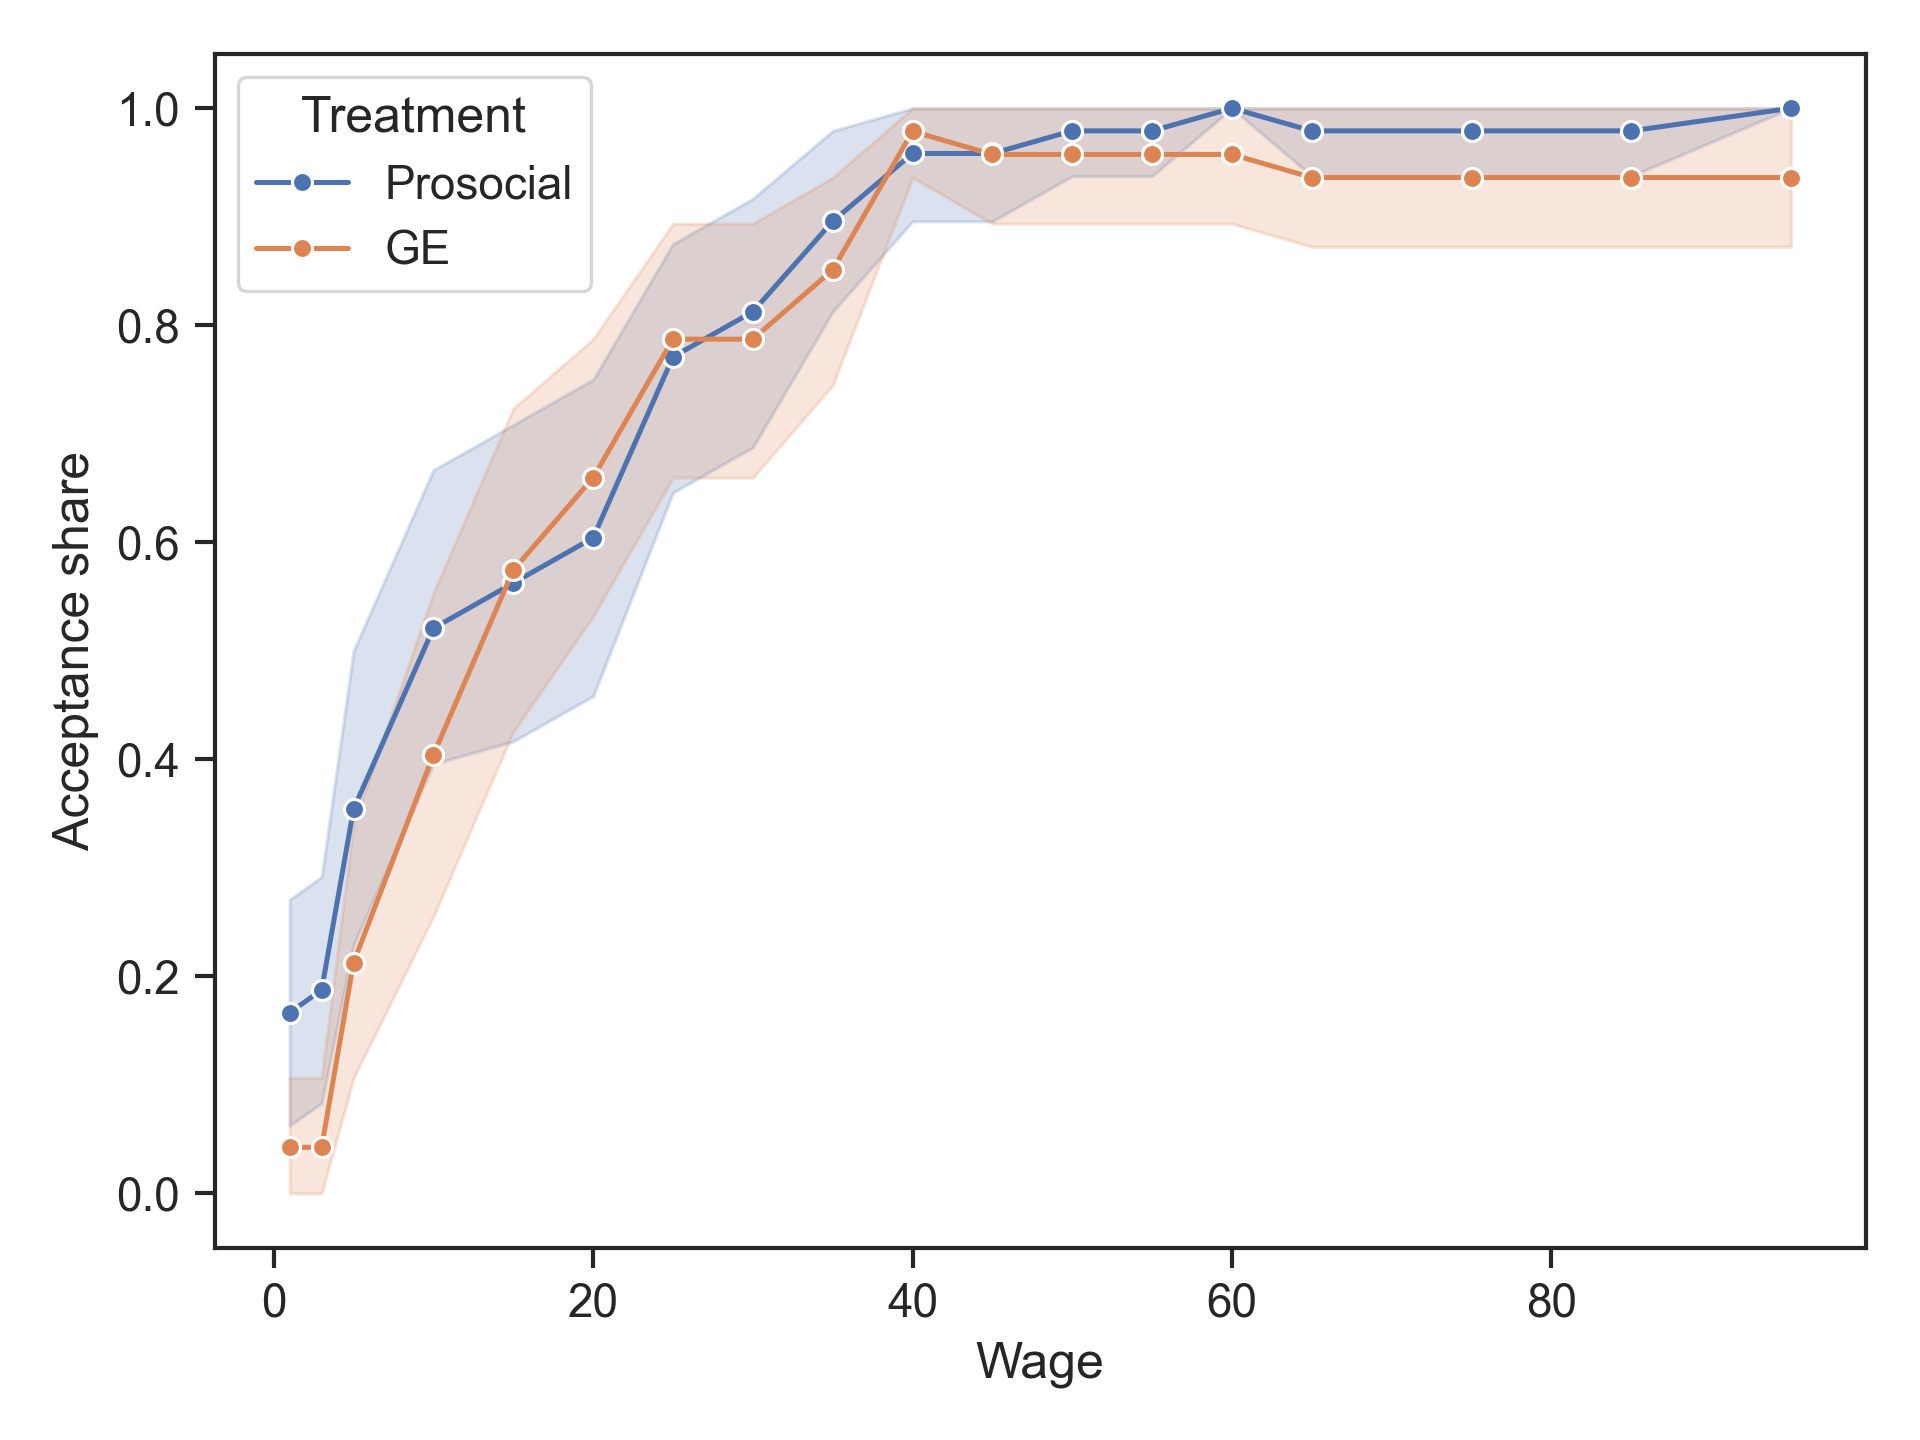

In [16]:
acceptance = agent_wage_long[agent_wage_long["Treatment"].isin(["P", "S"])].copy()
acceptance["Treatment"] = acceptance["treatment_label"]
sns.lineplot(data=acceptance, x="Wage", y="Acceptance", hue="Treatment", marker="o", errorbar=("ci", 95), seed=BOOTSTRAP_SEED)
plt.ylabel("Acceptance share")
save_current_figure(APPENDIX_FIGURES / "supp_fig_a1_acceptance_wage.png")
display(Image(filename=str(APPENDIX_FIGURES / "supp_fig_a1_acceptance_wage.png")))


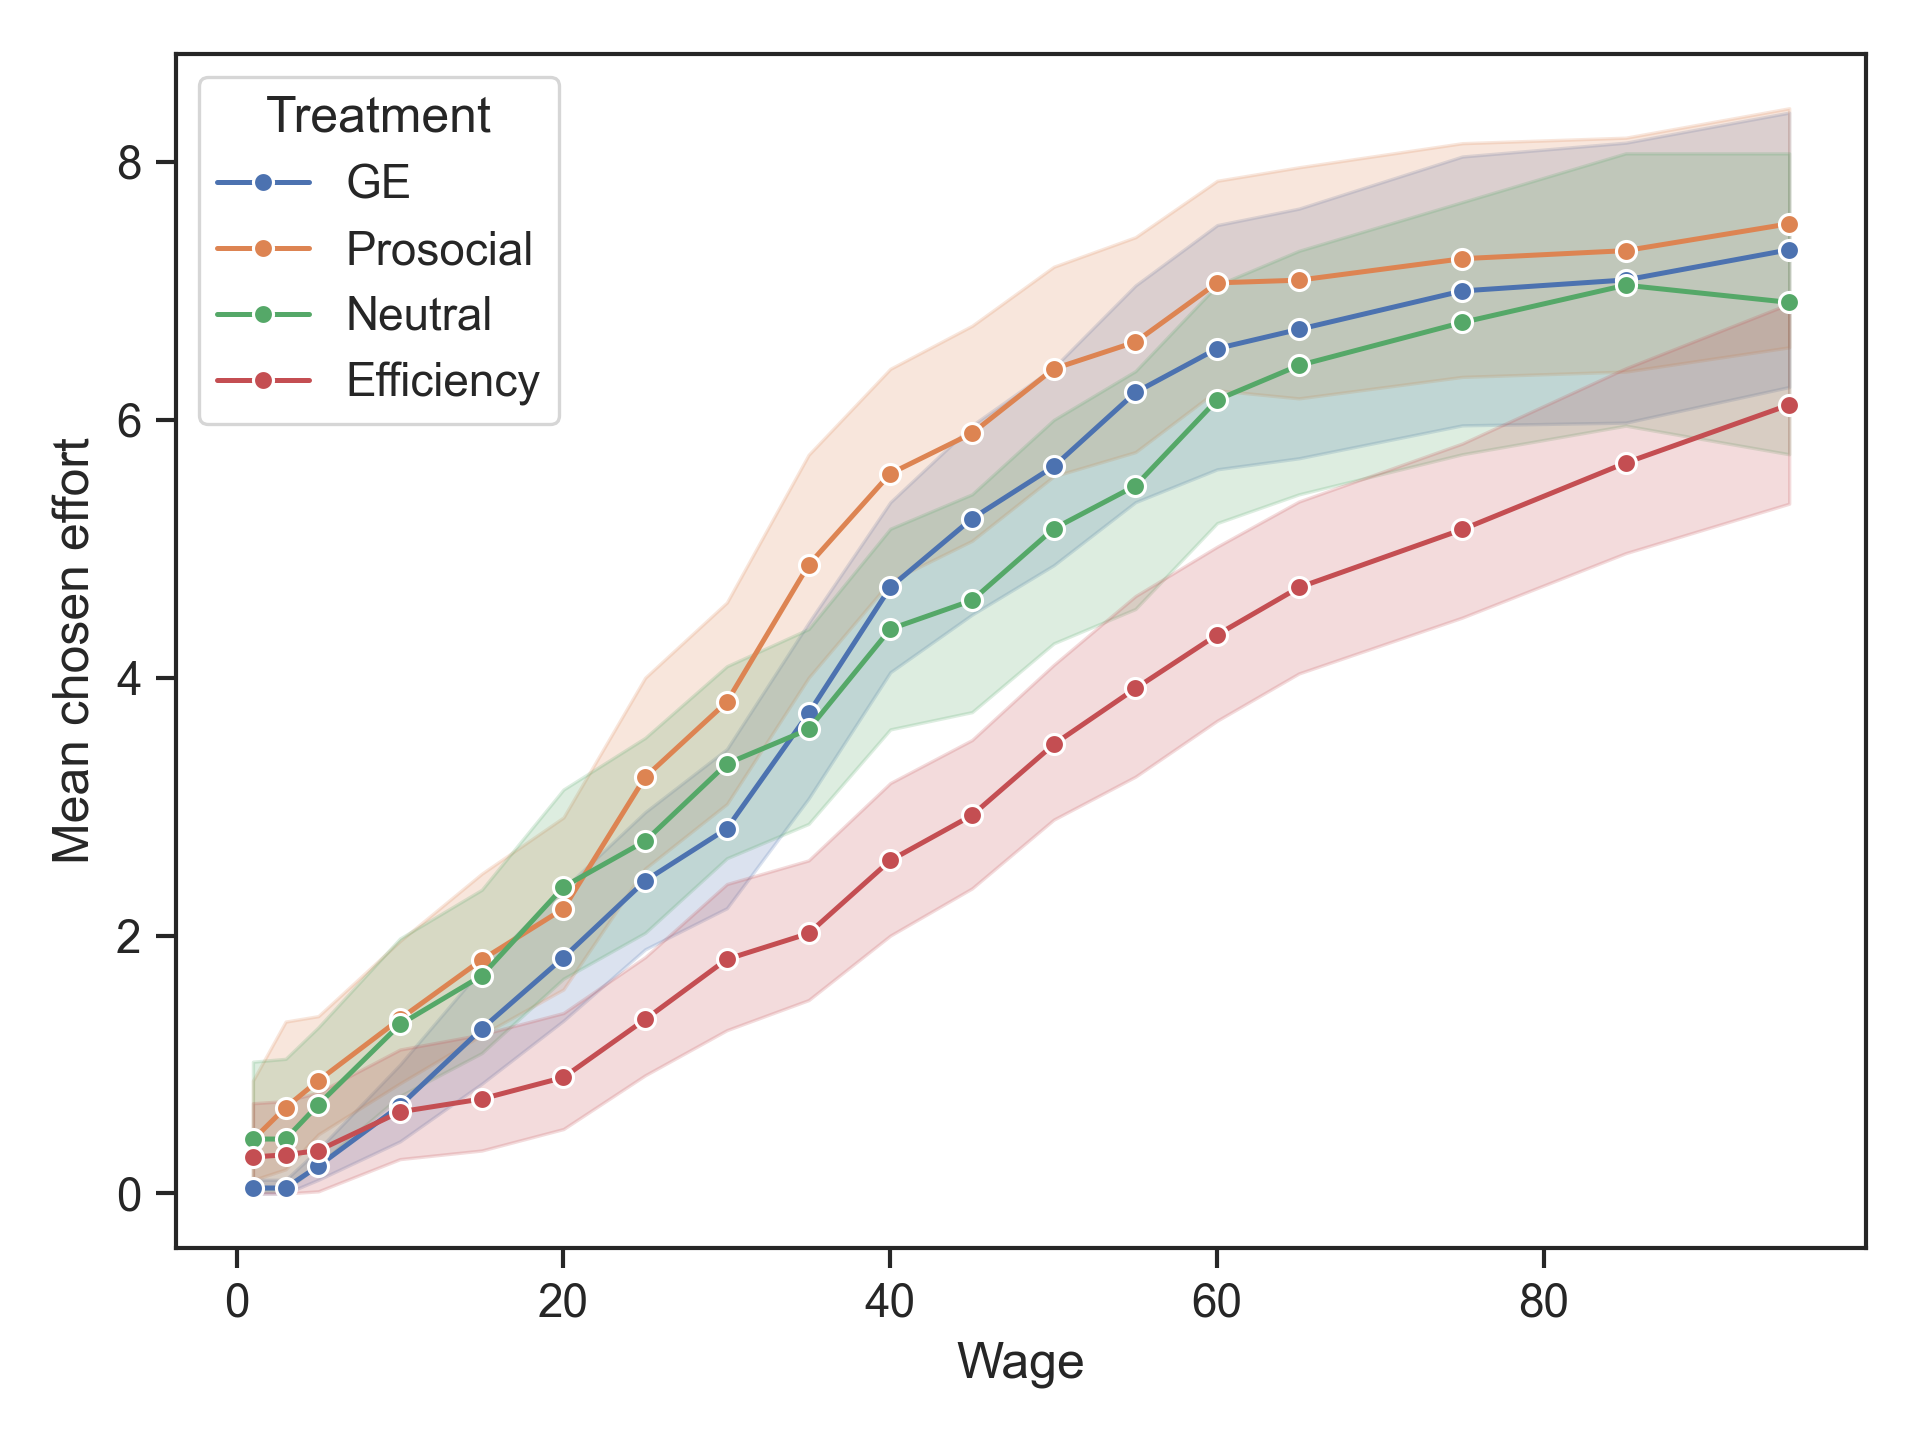

In [17]:
all_effort = agent_wage_long.copy()
all_effort["Treatment"] = pd.Categorical(all_effort["treatment_label"], categories=DISPLAY_ORDER, ordered=True)
sns.lineplot(data=all_effort, x="Wage", y="Effort", hue="Treatment", marker="o", errorbar=("ci", 95), seed=BOOTSTRAP_SEED)
plt.ylabel("Mean chosen effort")
save_current_figure(APPENDIX_FIGURES / "supp_fig_a2_chosen_effort_all.png")
display(Image(filename=str(APPENDIX_FIGURES / "supp_fig_a2_chosen_effort_all.png")))


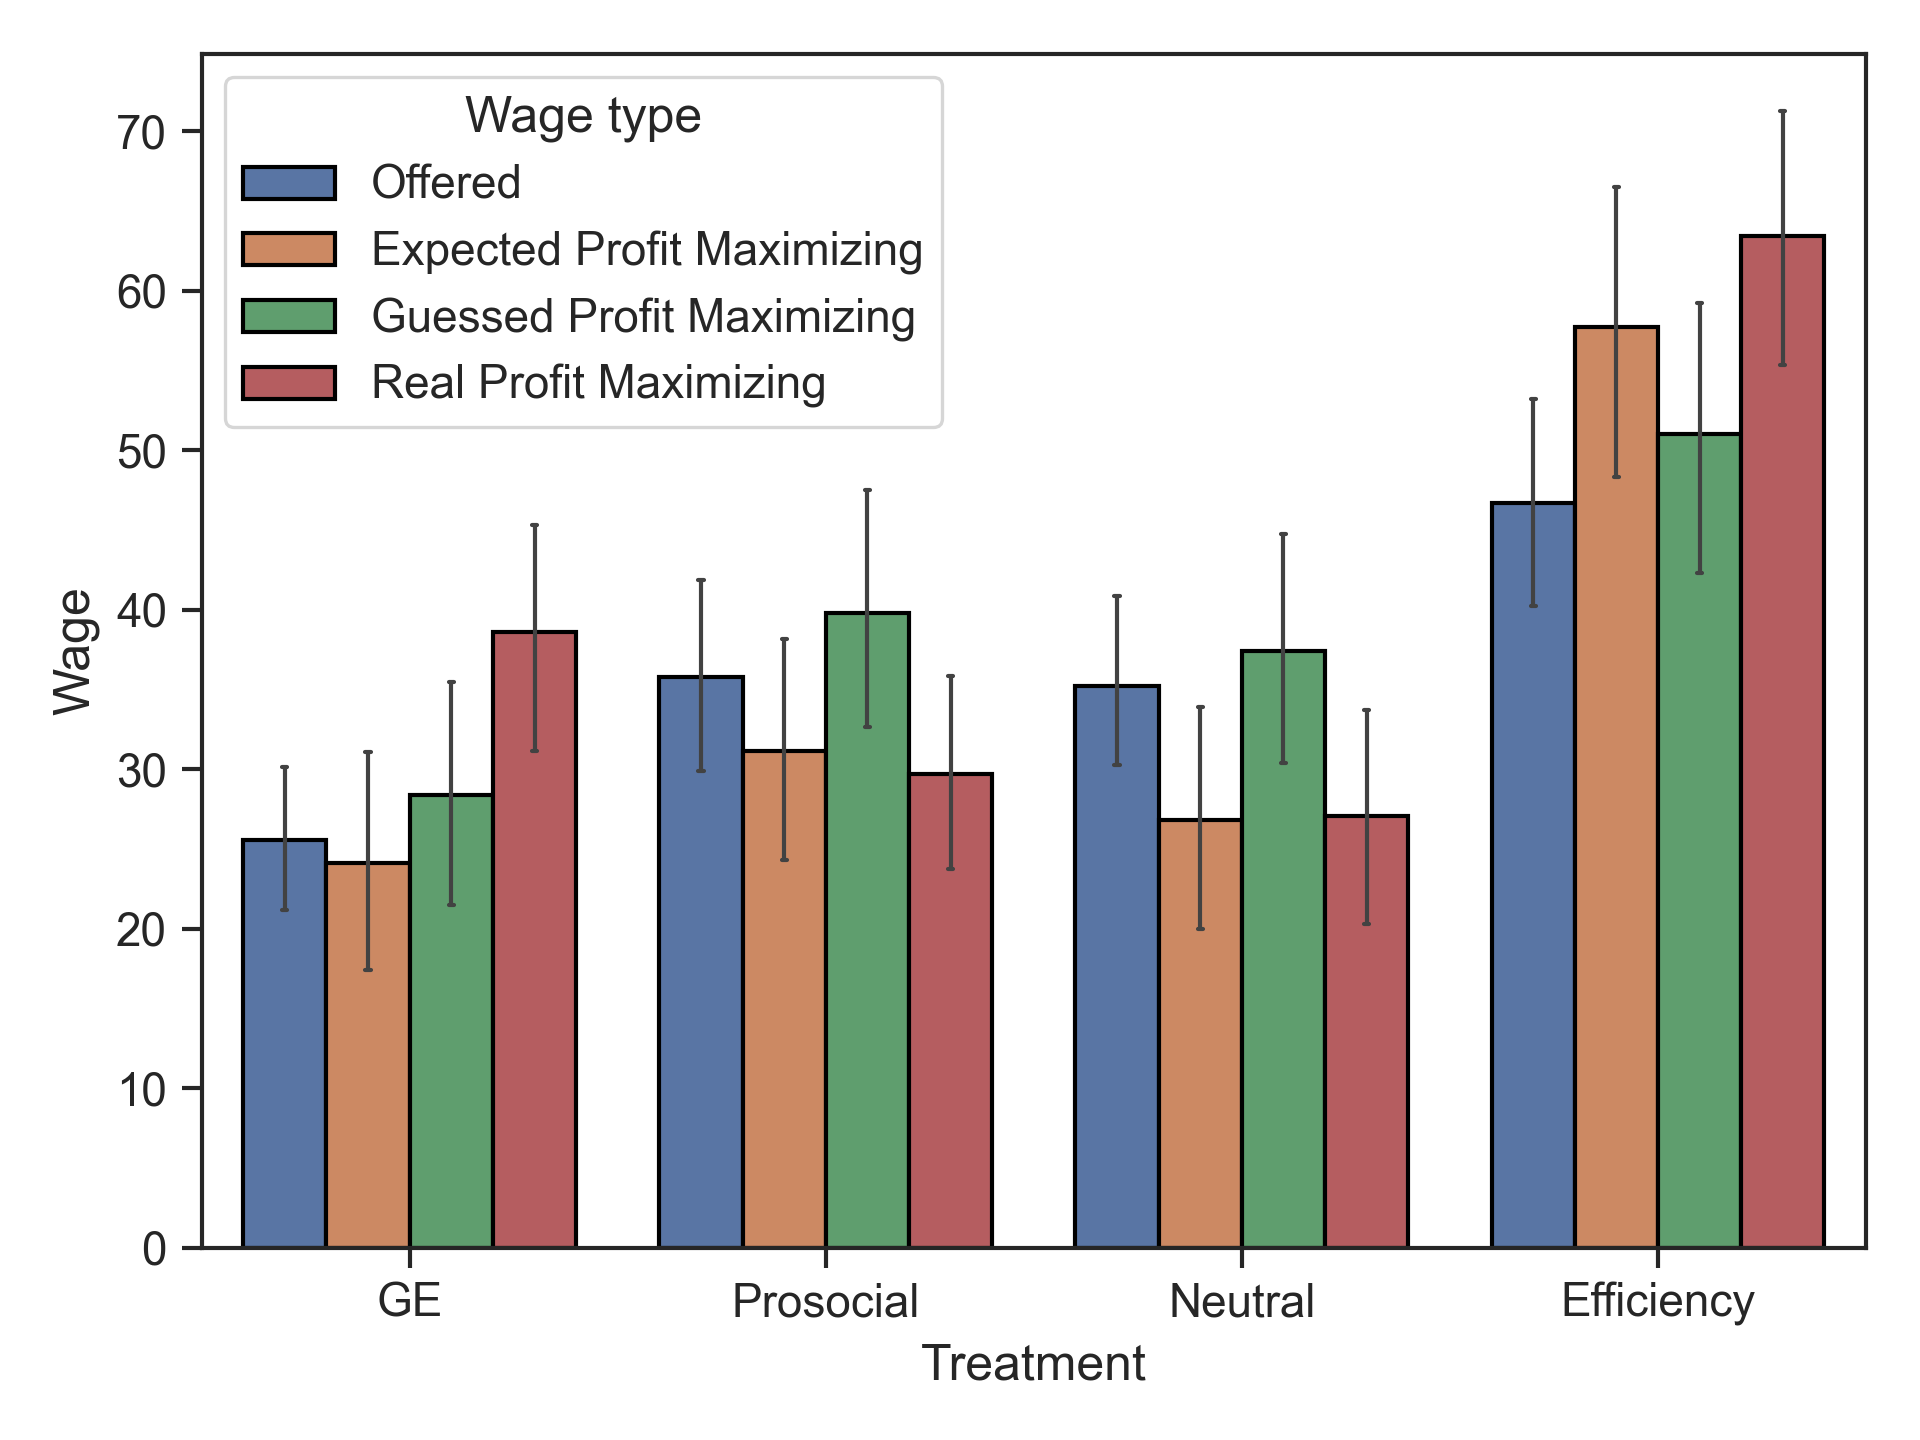

In [18]:

plot_wage_comparison(wage_summary, DISPLAY_ORDER)
save_current_figure(APPENDIX_FIGURES / "supp_fig_a3_wage_comparisons_all.png")
display(Image(filename=str(APPENDIX_FIGURES / "supp_fig_a3_wage_comparisons_all.png")))


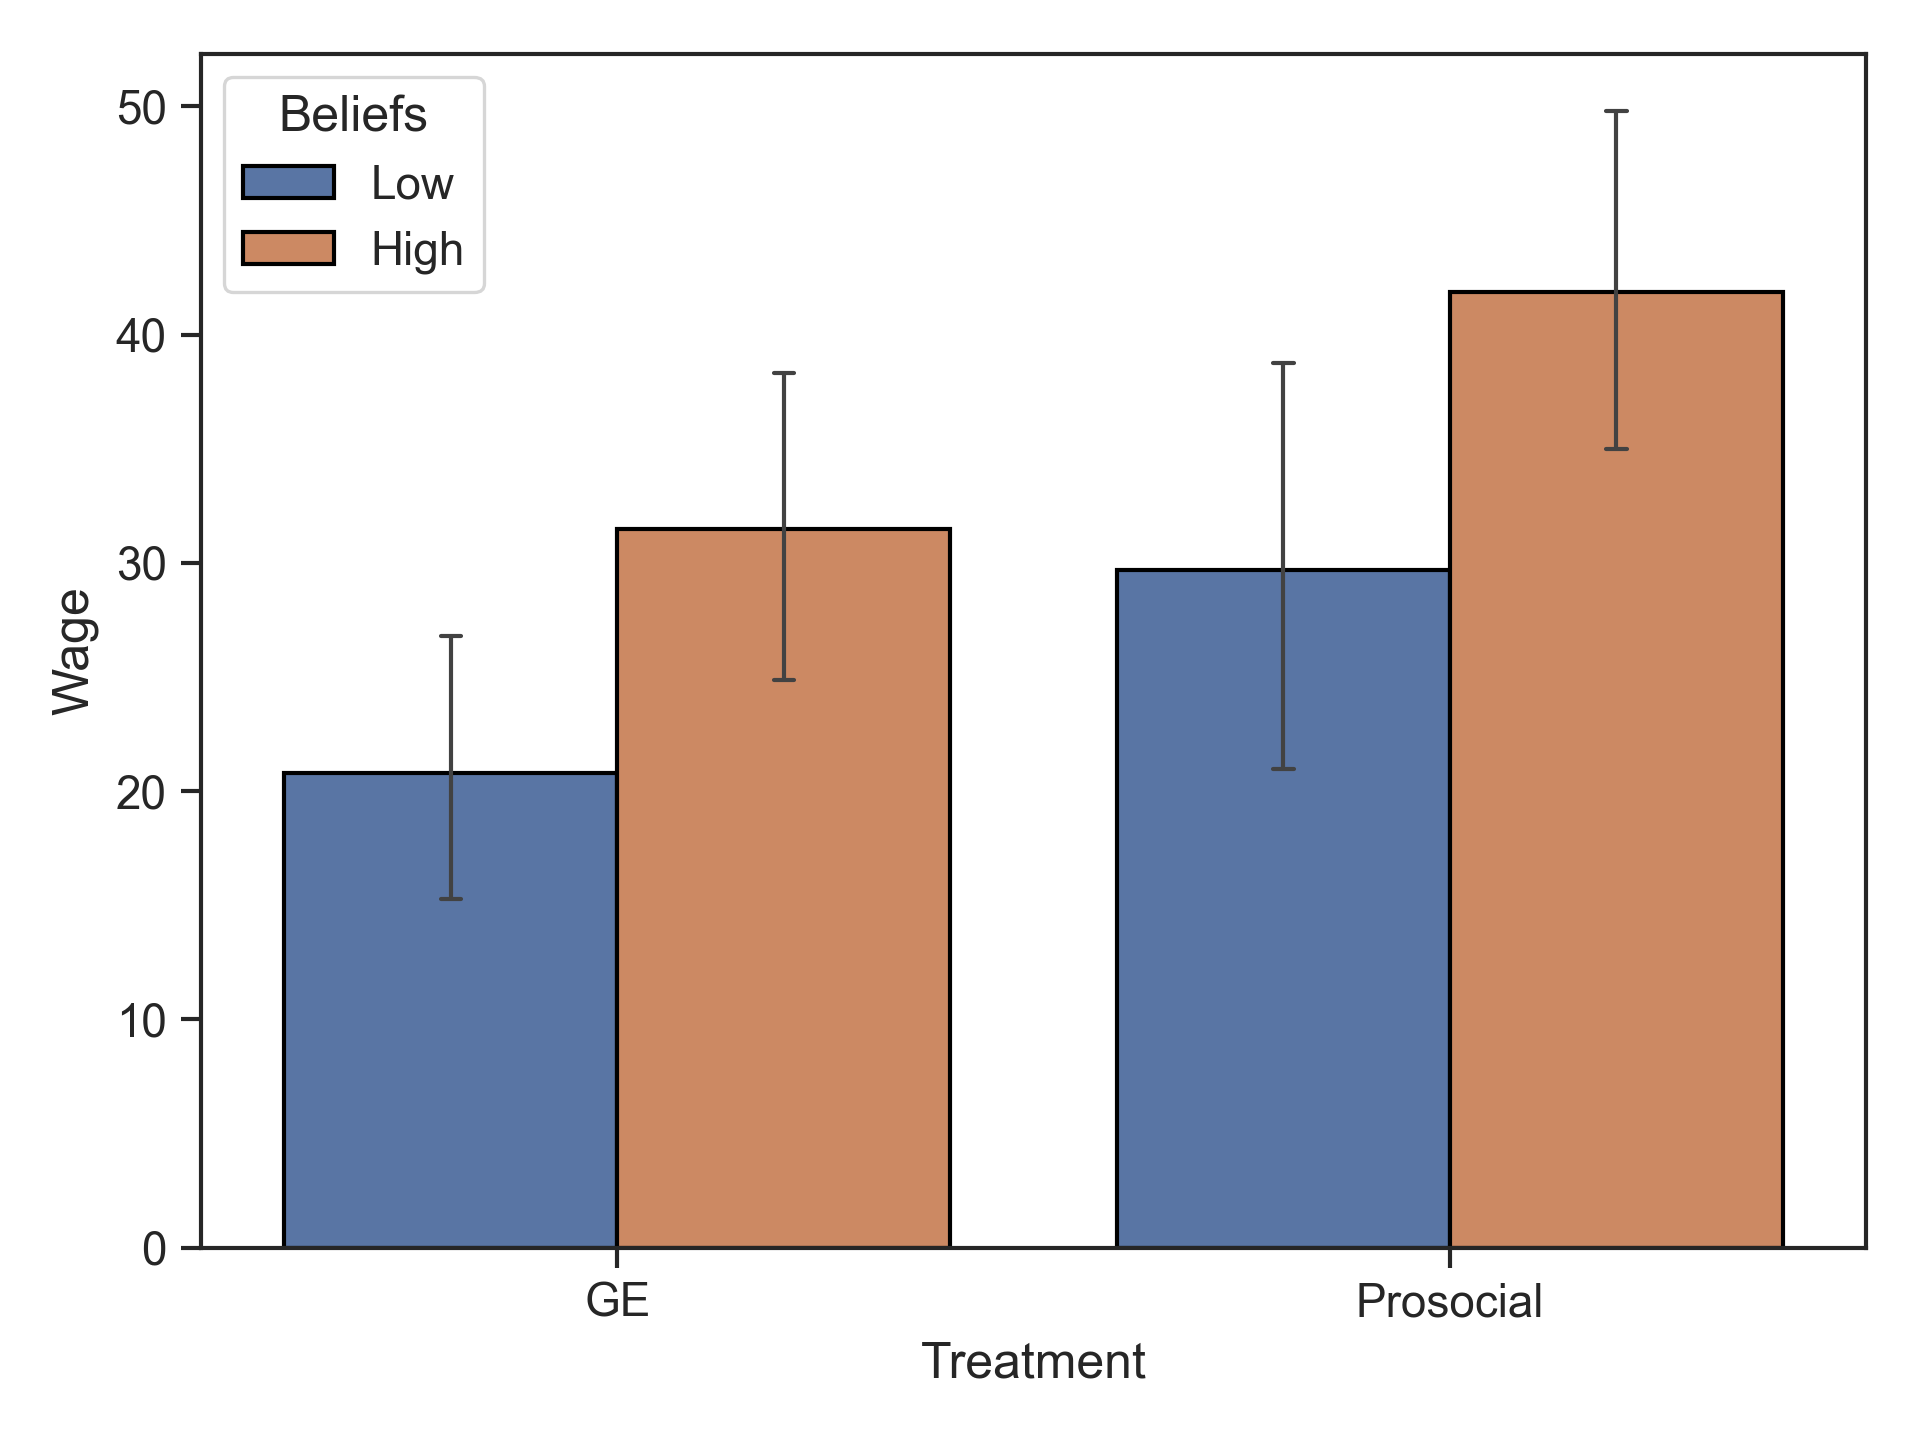

In [19]:

fig_a4 = wage_summary_by_principal[wage_summary_by_principal["Treatment label"].isin(["GE", "Prosocial"])].copy()
medians_beliefs = fig_a4.groupby("Treatment label")["expected_profitmax_wage"].transform("median")
fig_a4["Beliefs"] = np.where(fig_a4["expected_profitmax_wage"] <= medians_beliefs, "Low", "High")
sns.barplot(
    data=fig_a4,
    x="Treatment label",
    y="PAWage",
    hue="Beliefs",
    estimator=np.mean,
    errorbar=("ci", 95),
    seed=BOOTSTRAP_SEED,
    capsize=0.05,
    err_kws={"linewidth": 1},
    linewidth=1,
    edgecolor="black",
    order=["GE", "Prosocial"],
    hue_order=["Low", "High"],
)
plt.xlabel("Treatment")
plt.ylabel("Wage")
save_current_figure(APPENDIX_FIGURES / "supp_fig_a4_beliefs_based_profitmax_wage.png")
display(Image(filename=str(APPENDIX_FIGURES / "supp_fig_a4_beliefs_based_profitmax_wage.png")))


### Figure A.5. Individual effort, GE

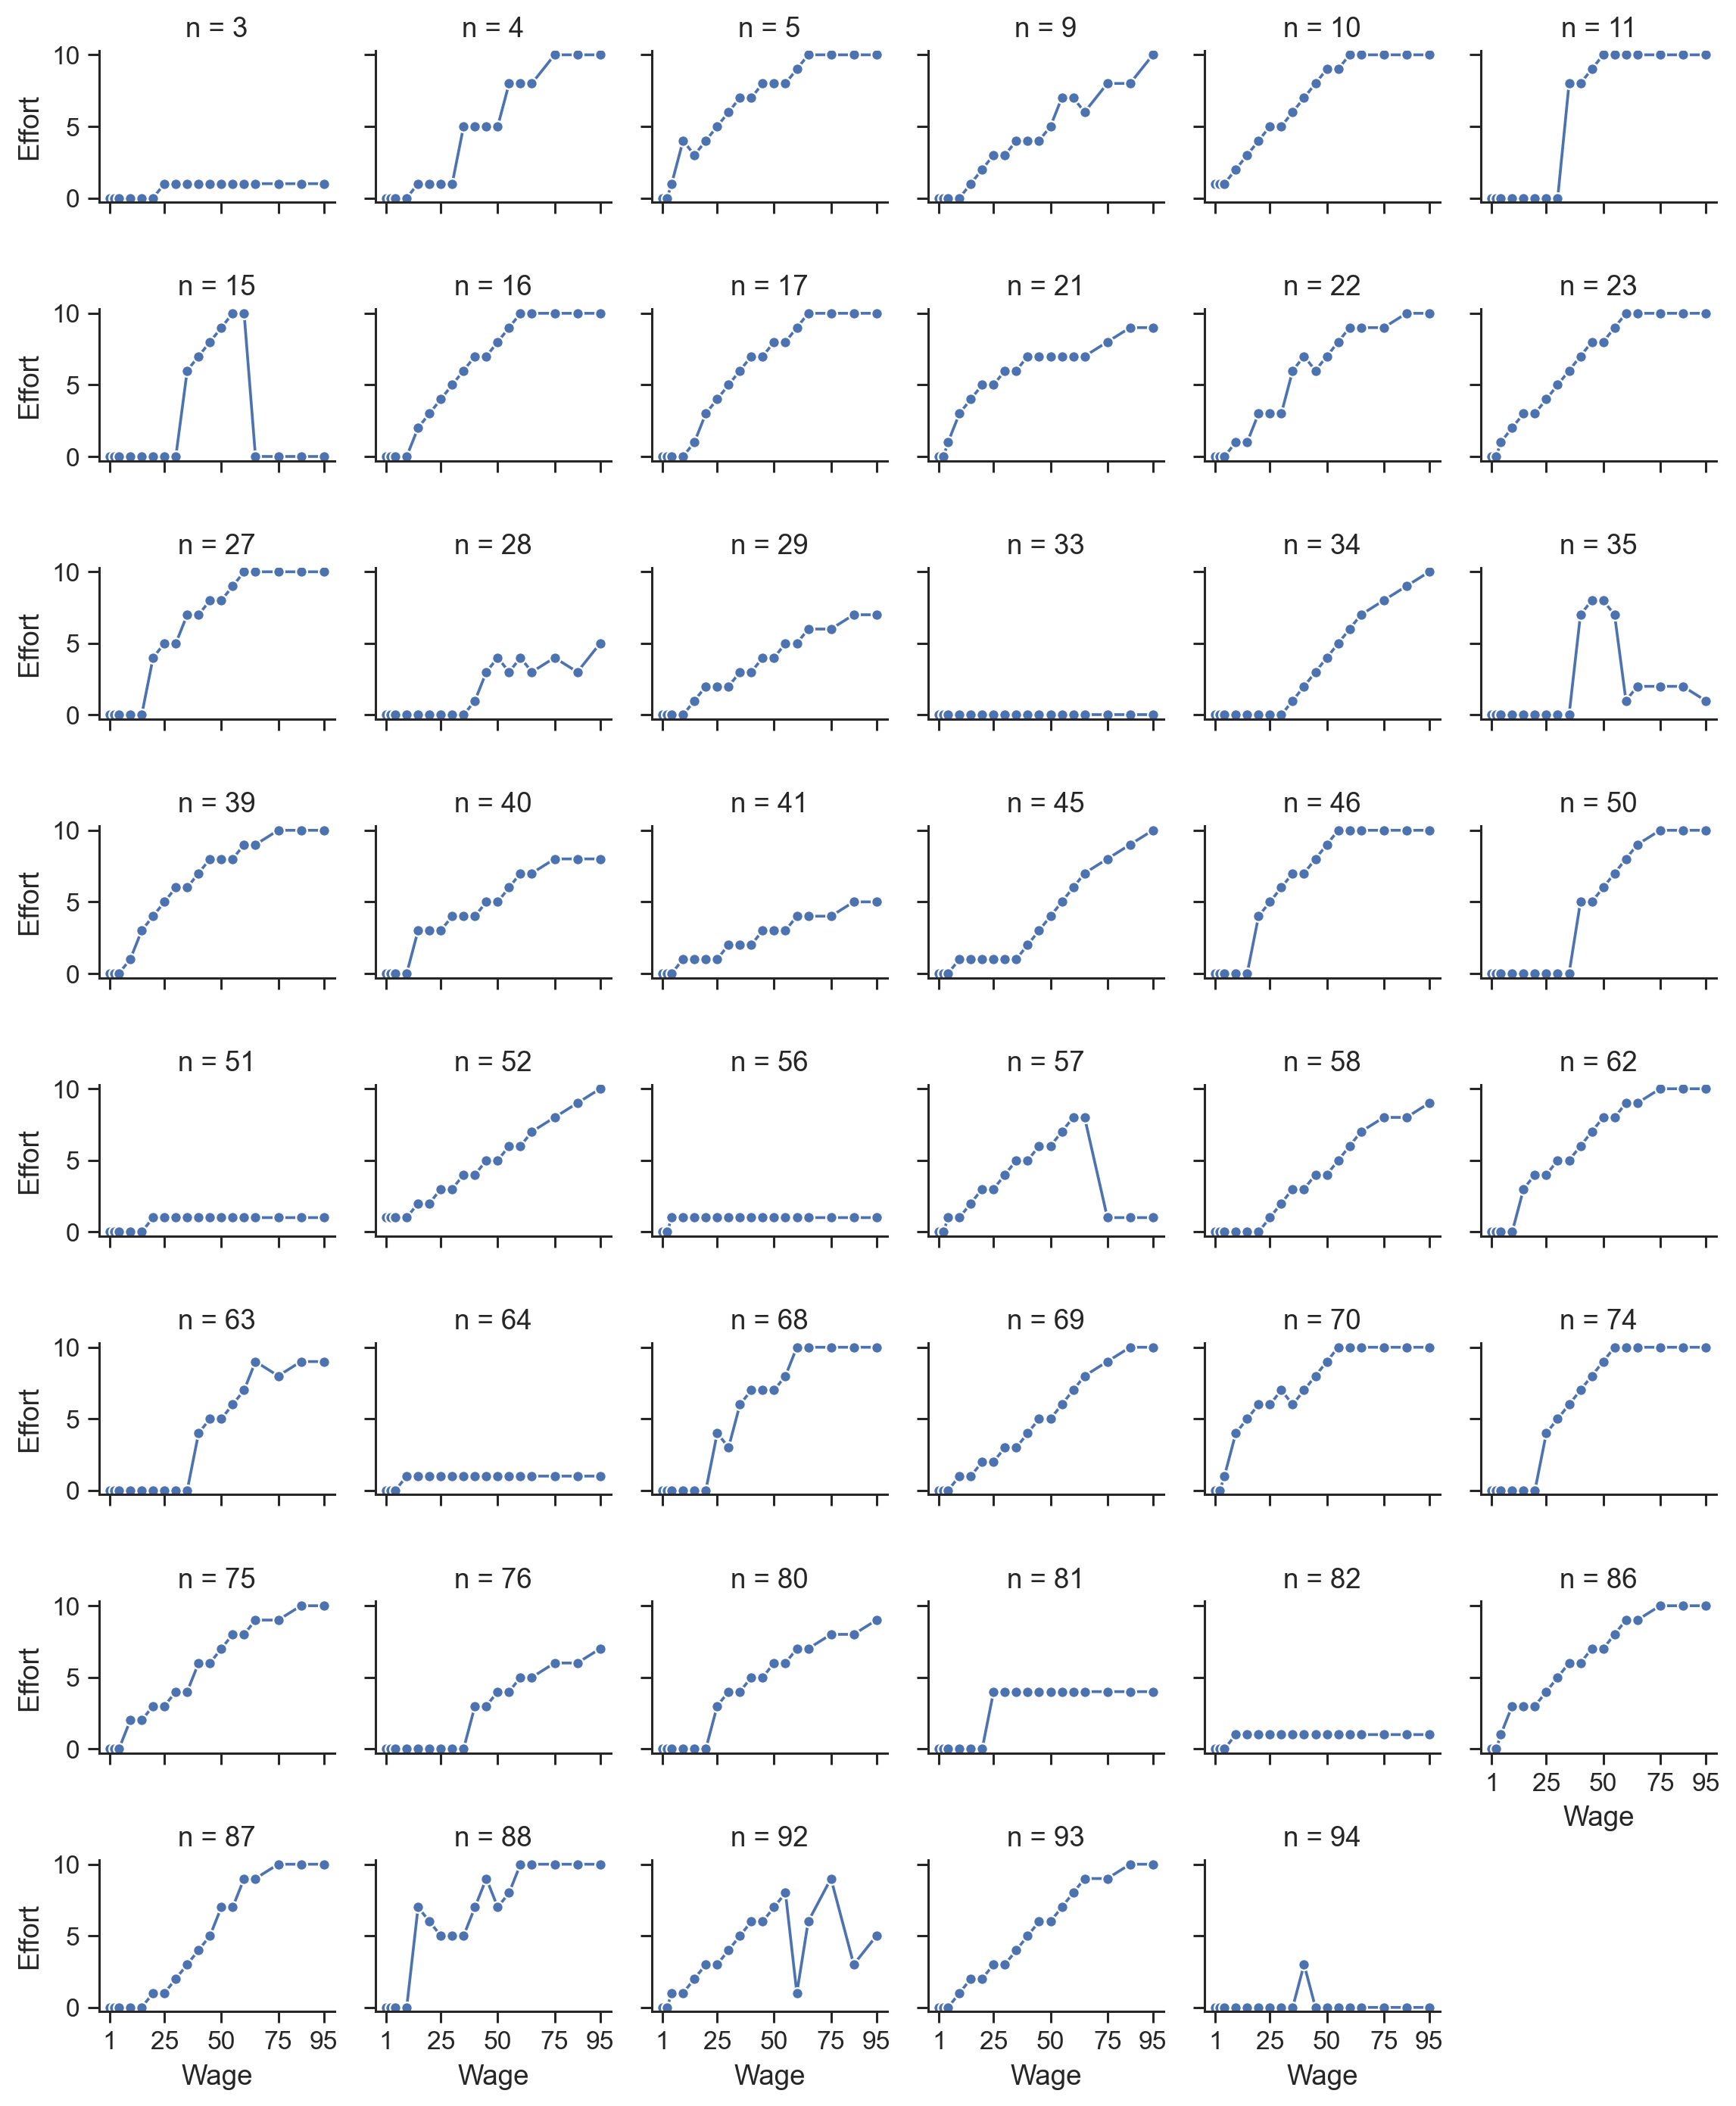

### Figure A.6. Individual effort, prosocial

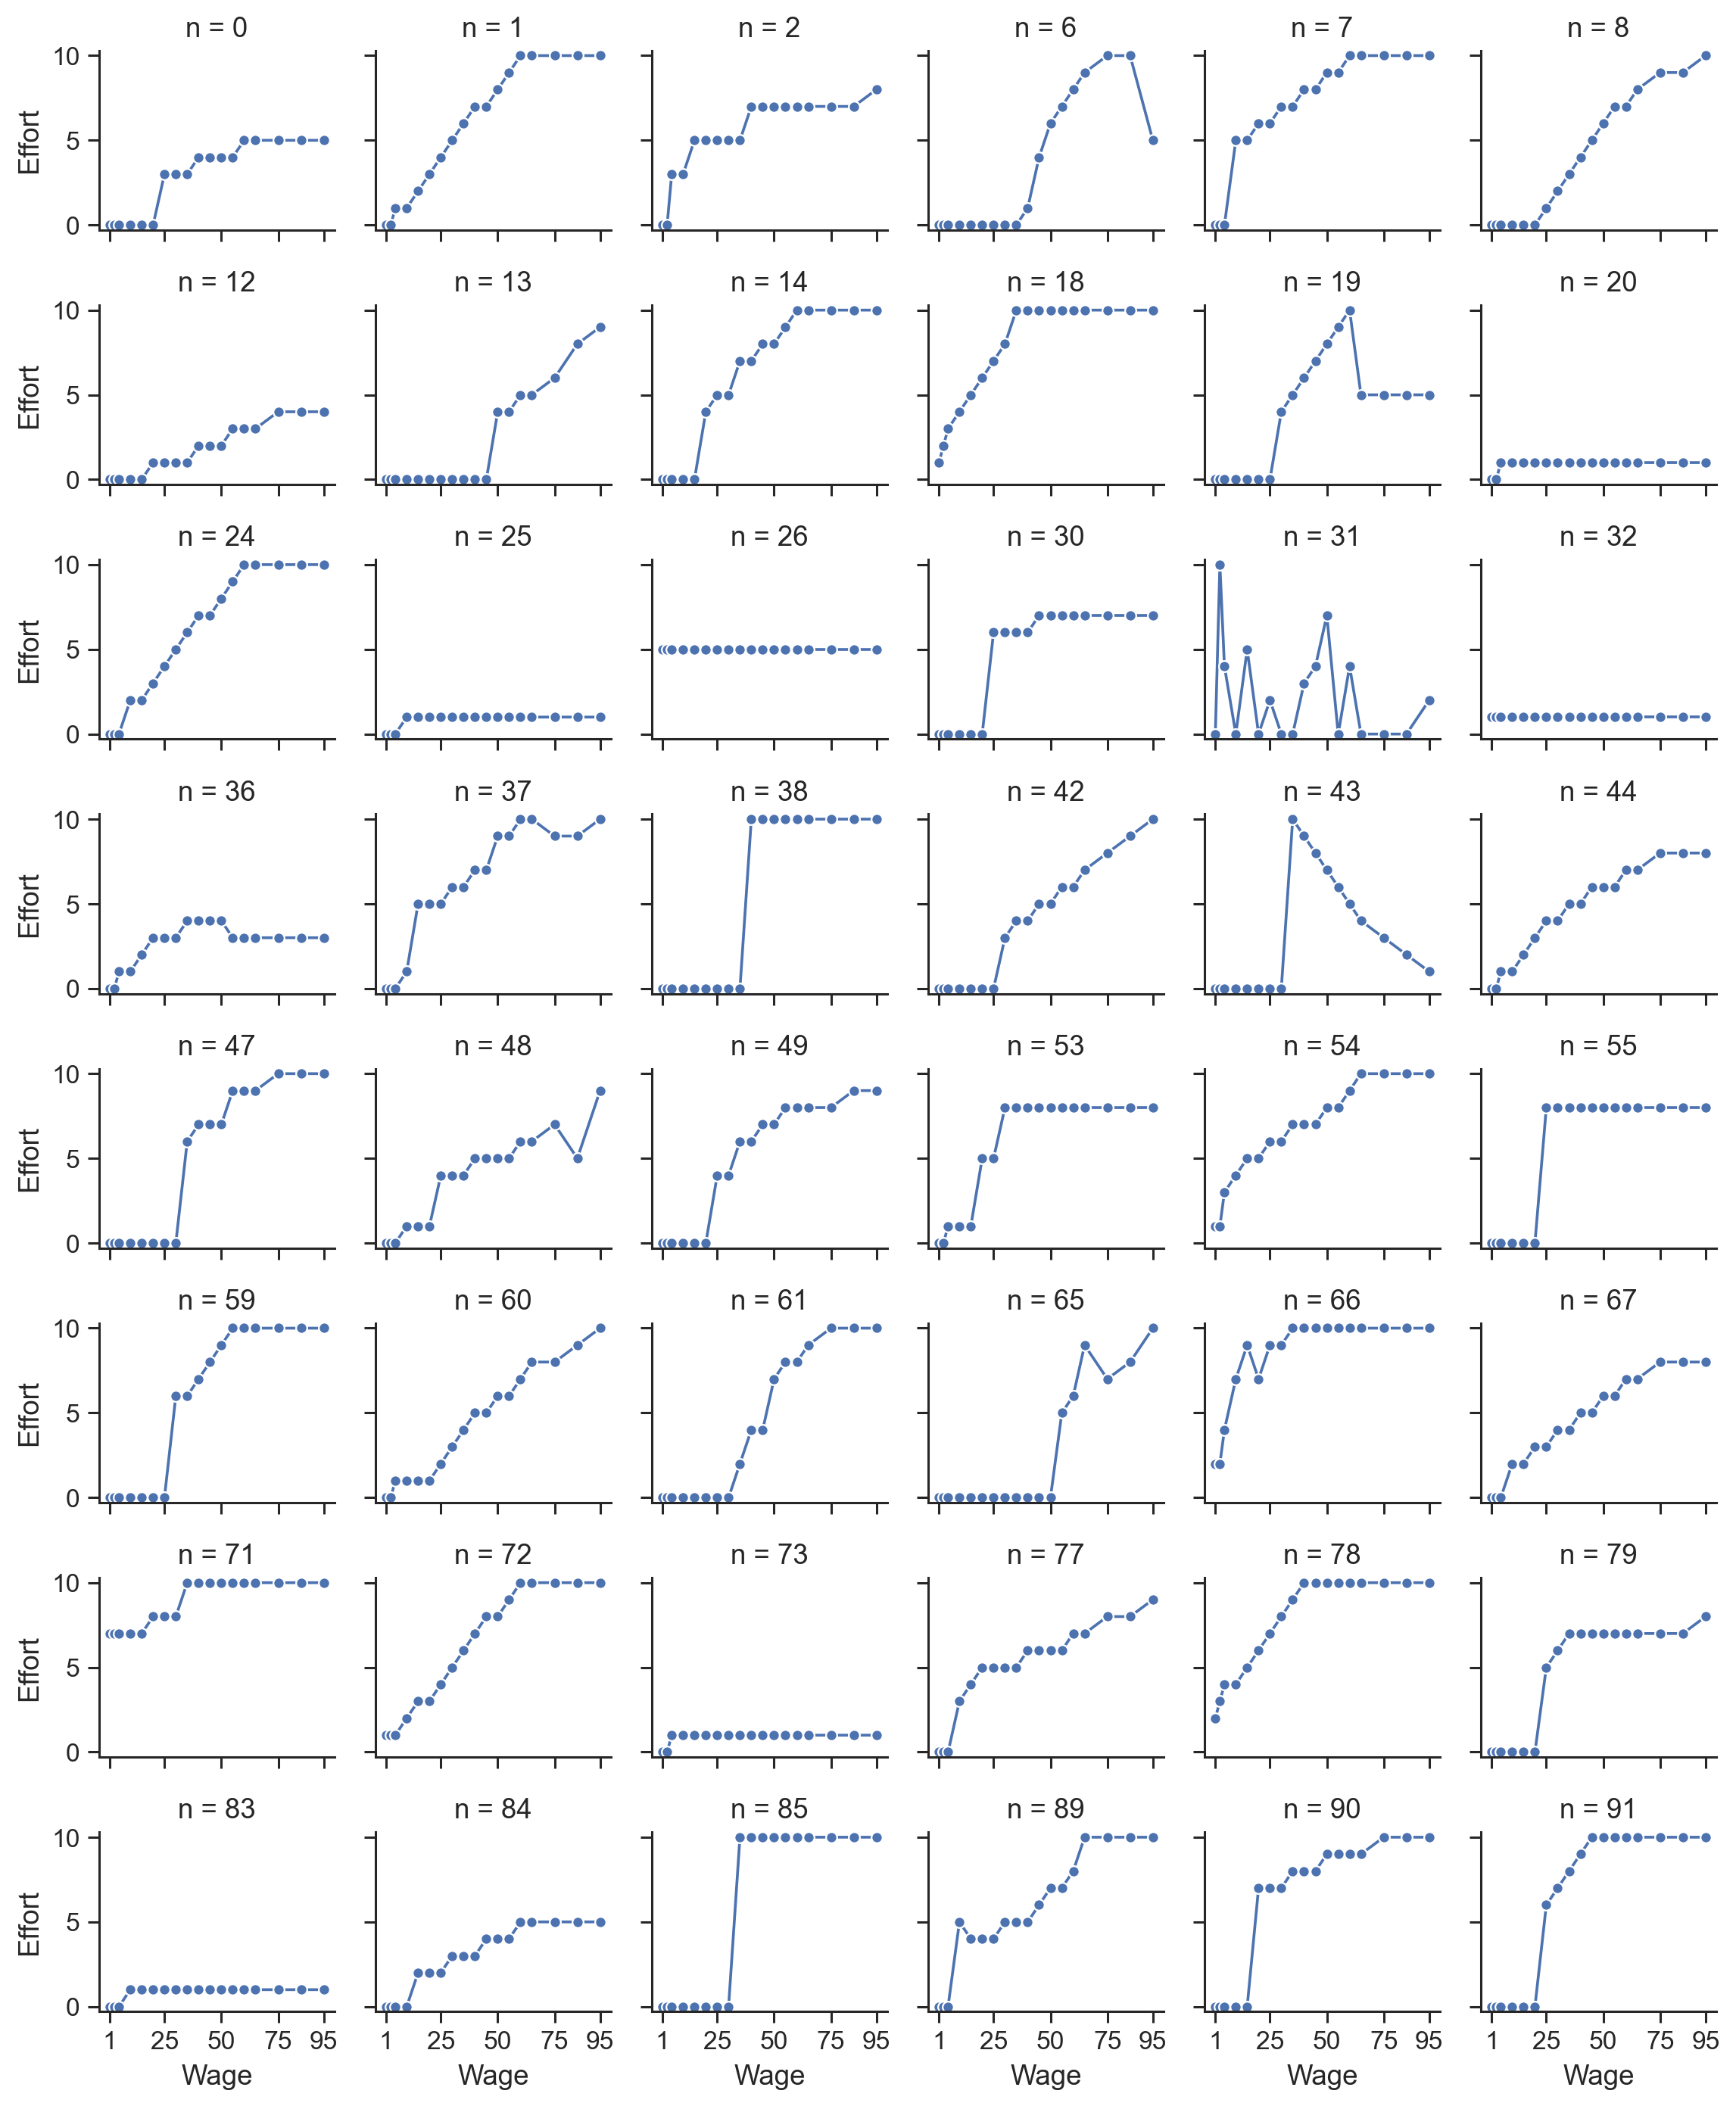

### Figure A.7. Individual effort, neutral

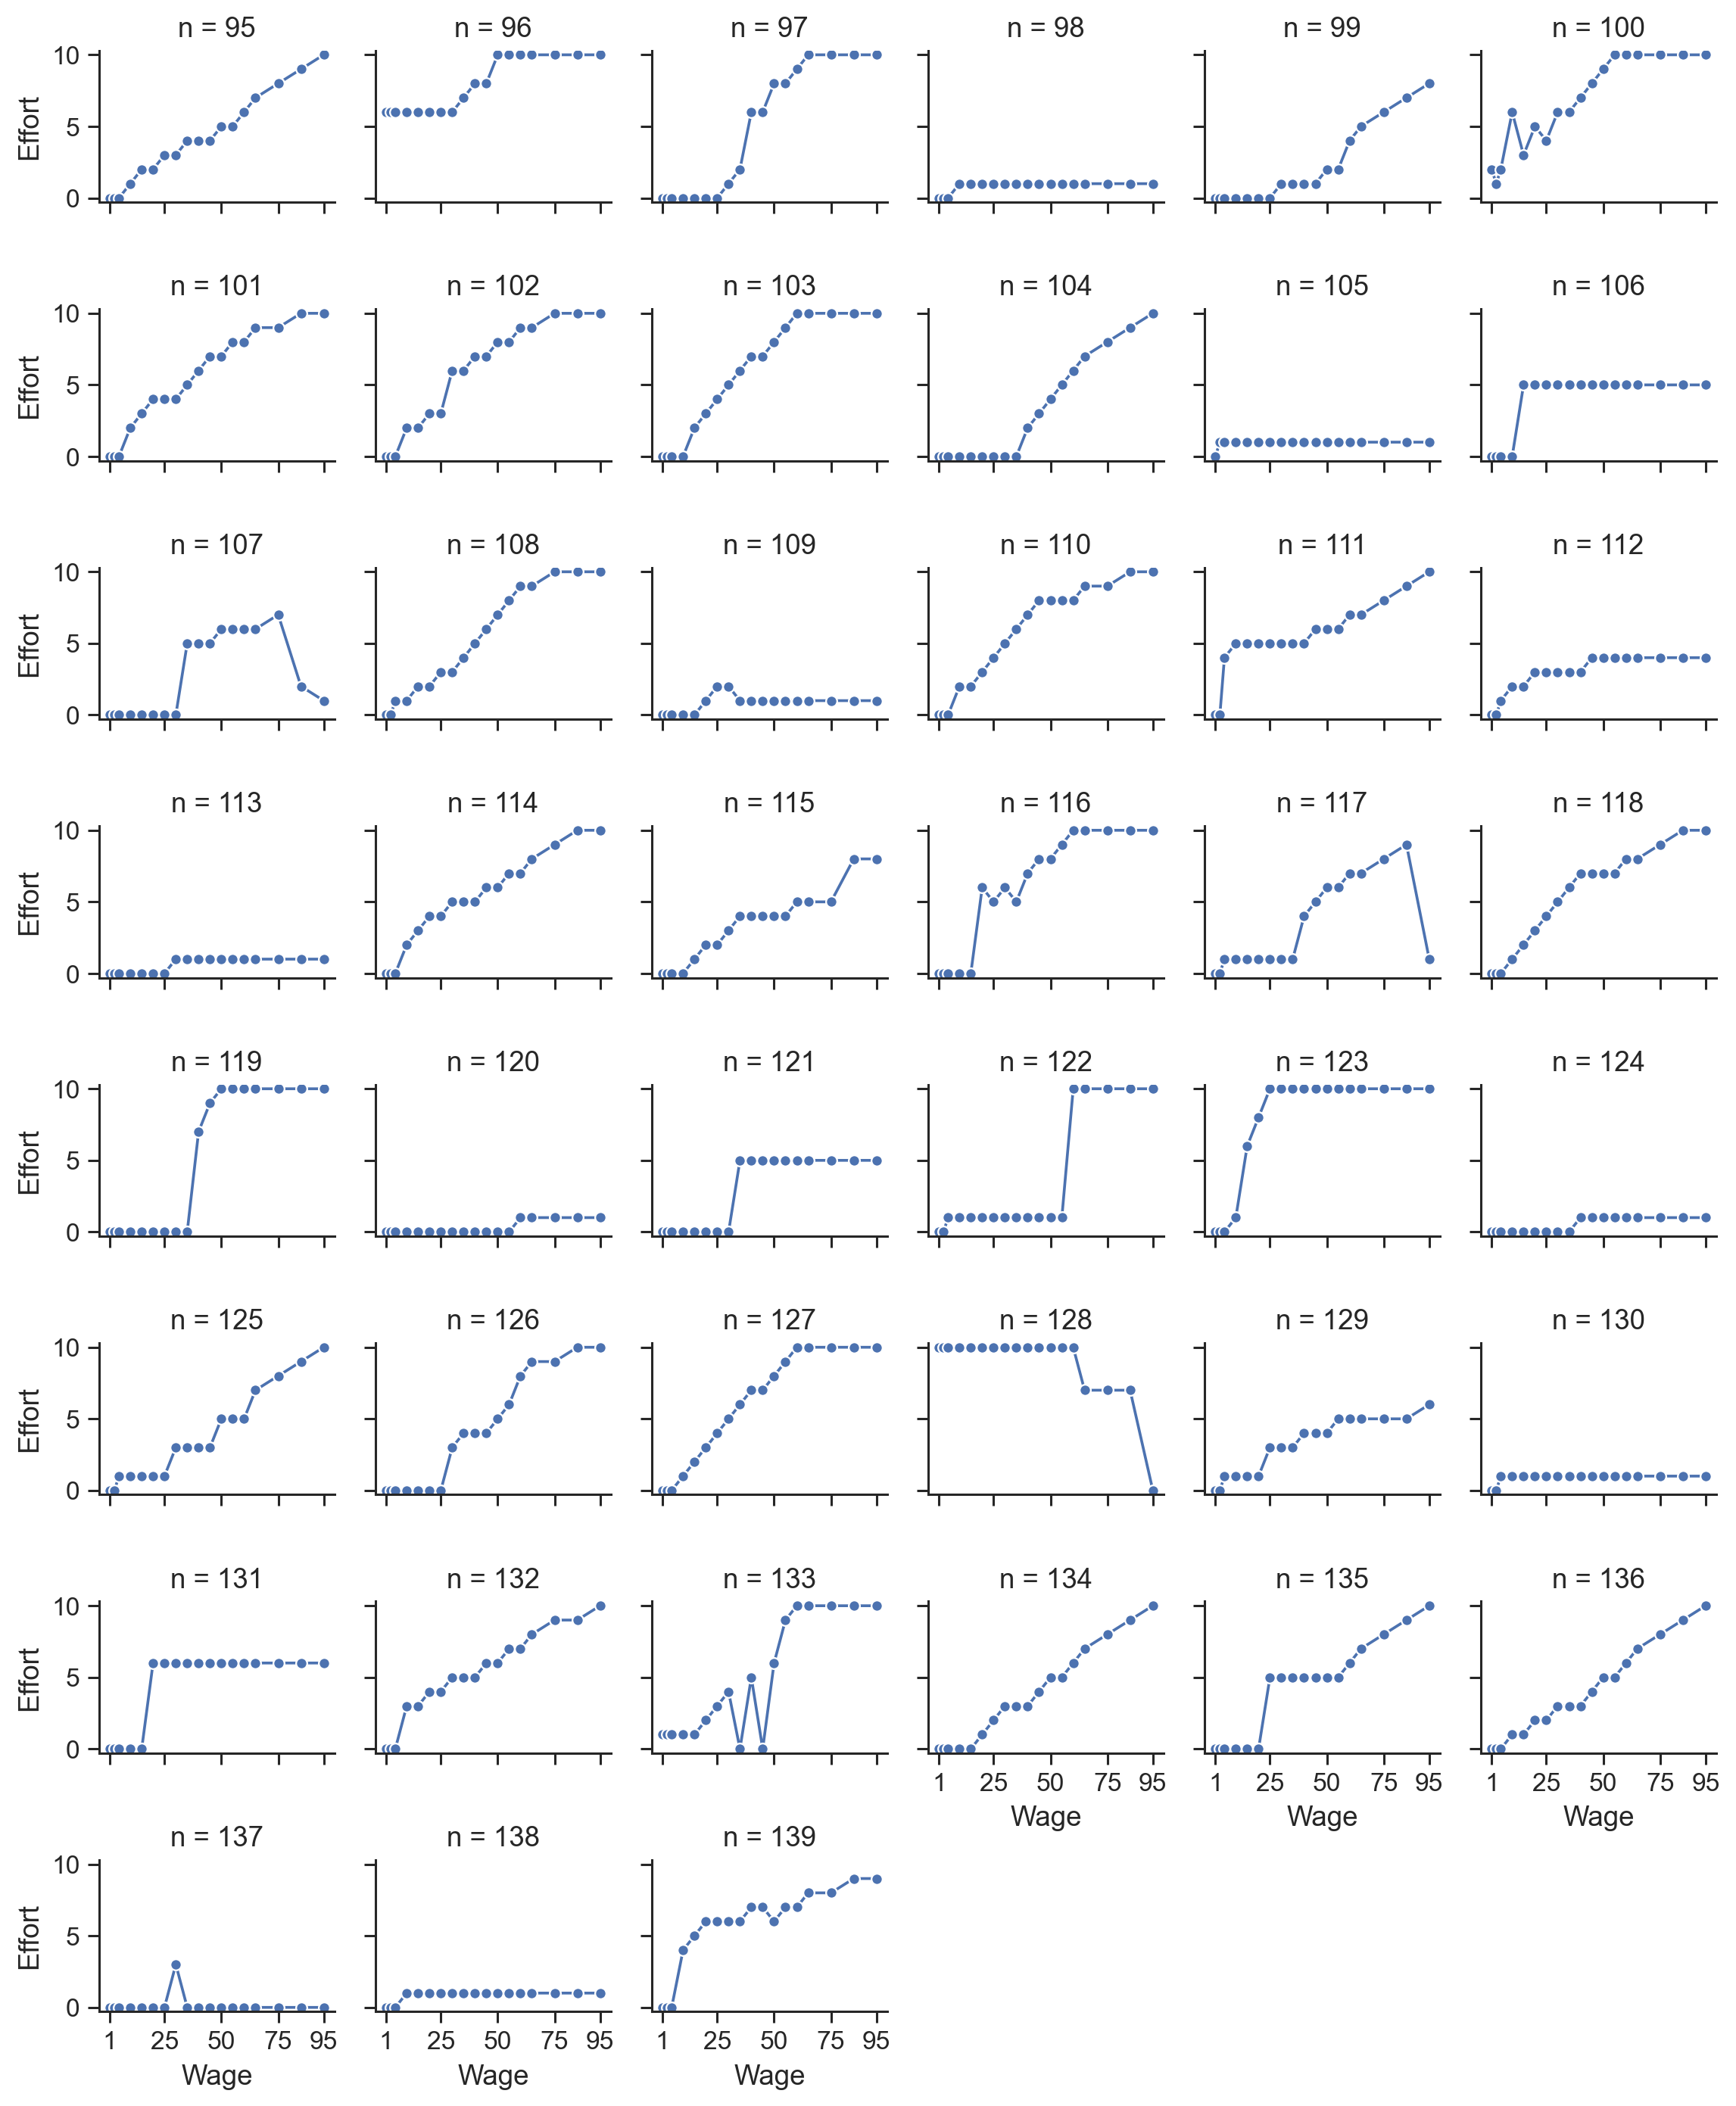

### Figure A.8. Individual effort, efficiency

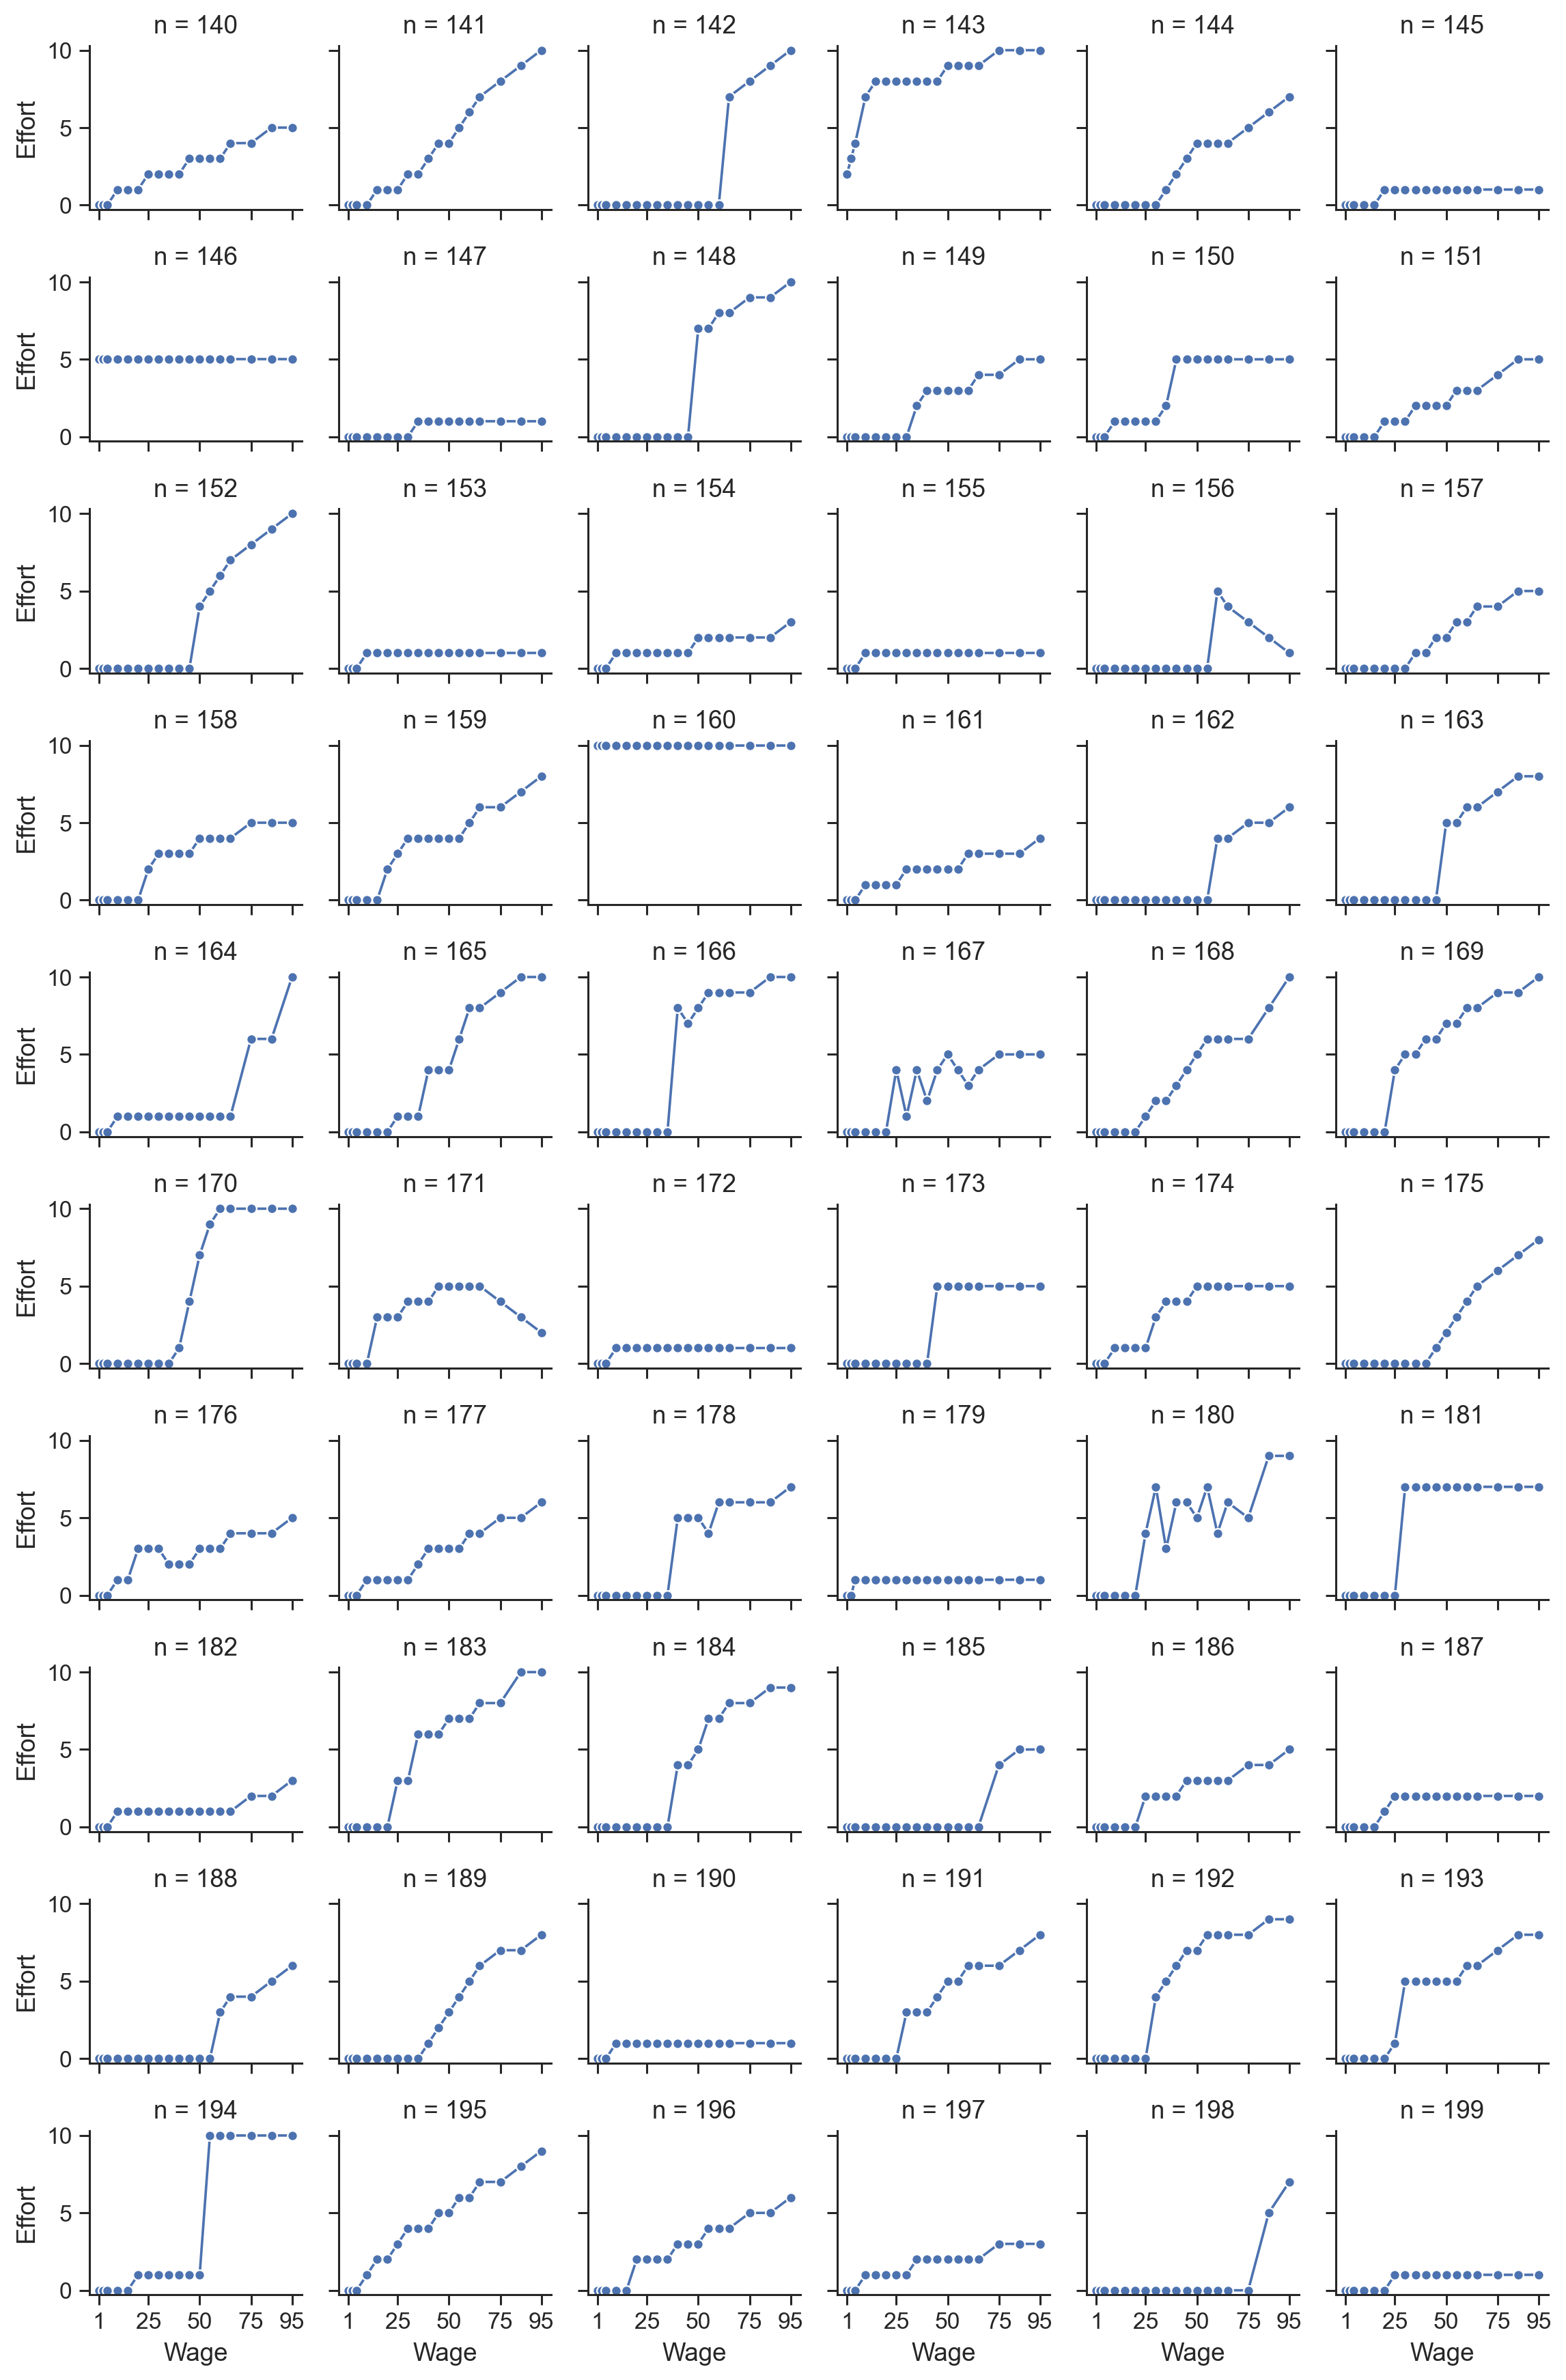

In [20]:
for treatment, title, filename in [
    ("P", "Figure A.5. Individual effort, GE", "supp_fig_a5_individual_effort_ge.png"),
    ("S", "Figure A.6. Individual effort, prosocial", "supp_fig_a6_individual_effort_prosocial.png"),
    ("N", "Figure A.7. Individual effort, neutral", "supp_fig_a7_individual_effort_neutral.png"),
    ("PAN", "Figure A.8. Individual effort, efficiency", "supp_fig_a8_individual_effort_efficiency.png"),
]:
    subset = agent_wage_long[agent_wage_long["Treatment"] == treatment].copy()
    g = sns.relplot(data=subset, x="Wage", y="Effort", col="n", col_wrap=6, kind="line", marker="o", height=1.6, aspect=1.1, errorbar=None)
    g.set(xticks=[1, 25, 50, 75, 95], yticks=[0, 5, 10], ylim=(-0.3, 10.3))
    g.set_axis_labels("Wage", "Effort")
    g.savefig(APPENDIX_FIGURES / filename, dpi=220)
    plt.close("all")
    display(Markdown(f"### {title}"))
    display(Image(filename=str(APPENDIX_FIGURES / filename)))